<a href="https://colab.research.google.com/github/camilajaen16-ops/cda/blob/main/DASHBOARD_TRABAJO_FINAL_Sistema_Alerta_Temprana_PM_Constancia_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de Alerta Temprana de Material Particulado — U.M. Constancia (Cusco)

Flujo:
1. Carga y limpieza robusta del dataset (5 min)
2. Exploración y diagnóstico de integridad
3. Reestructuración a formato largo y **regularización a rejilla de 5 min**
   
4. Red de monitoreo, estaciones válidas e **imputación de huecos cortos por
   duración real** (agnóstica a la frecuencia)
5. Análisis exploratorio
6. Feature engineering (**rezagos y ventanas reescalados a 5 min** + suavizado) +
   modelo base LightGBM




## 0. Instalación de librerías

Se instalan aquí todas las librerías del proyecto. El modelo de comparación de
la Sección 20 es un **Random Forest** (scikit-learn, ya incluido en Colab), así
que ya no hacen falta las librerías pesadas de deep learning (PyTorch /
pytorch-forecasting / lightning).

In [ ]:
# (pandas, numpy, matplotlib, seaborn y scikit-learn ya vienen en Colab)
!pip install -q gdown pyarrow missingno windrose lightgbm statsmodels scipy joblib

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re, csv, warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (11, 5)
print("pandas", pd.__version__)

pandas 2.2.2


## 1. Conseguir y preparar los datos: 4 años de aire, en un DataSet
Toda proyección confiable empieza por la materia prima. En esta etapa, vamos a importar, analizar, depurar y estructurar el *dataset* histórico de las estaciones internas de la U.M. Constancia. Limpiaremos valores nulos, ajustaremos las series de tiempo y dejaremos la información estructurada para el modelo de Machine Learning y su posterior cruce con la data de OEFA.

1. Carga del dataset desde Google Drive
Se usa gdown con el ID

In [ ]:
import gdown
FILE_ID  = "1XPwk5TDVkTvUgPgokLKkXkeM8I9jy98t"
CSV_PATH = "constancia.csv"
gdown.download(id=FILE_ID, output=CSV_PATH, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1XPwk5TDVkTvUgPgokLKkXkeM8I9jy98t
To: /content/constancia.csv
100%|██████████| 56.5M/56.5M [00:00<00:00, 61.5MB/s]


'constancia.csv'

### Carga robusta del CSV
Los export de Excel en español suelen usar separador `;` y decimal `,`.
Esta función detecta automáticamente **encoding, separador y signo decimal**.

In [ ]:
def cargar_csv_robusto(path):
    # 1) Detectar encoding
    encoding = None
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            with open(path, "r", encoding=enc) as f:
                muestra = f.read(5000)
            encoding = enc
            break
        except UnicodeDecodeError:
            continue
    # 2) Detectar separador
    try:
        sep = csv.Sniffer().sniff(muestra, delimiters=",;\t|").delimiter
    except Exception:
        sep = ";" if muestra.count(";") > muestra.count(",") else ","
    # 3) Inferir signo decimal
    decimal = "," if sep == ";" else "."
    print(f"Encoding={encoding} | Separador={sep!r} | Decimal={decimal!r}")
    df = pd.read_csv(path, sep=sep, encoding=encoding, decimal=decimal, low_memory=False)
    # 4) Validación: si casi nada quedó numérico, reintentar con el otro decimal
    n_num = df.apply(lambda col: pd.to_numeric(col, errors="coerce").notna().mean()).gt(0.5).sum()
    if n_num < 3:
        alt = "." if decimal == "," else ","
        print(f"Pocas columnas numéricas; reintentando con decimal={alt!r}")
        df = pd.read_csv(path, sep=sep, encoding=encoding, decimal=alt, low_memory=False)
    return df

# Primero miramos las primeras líneas CRUDAS para entender la estructura:
print("----- Primeras líneas del archivo -----")
with open(CSV_PATH, "r", encoding="latin-1") as f:
    for _ in range(3):
        print(repr(f.readline()))
print("---------------------------------------\n")

df = cargar_csv_robusto(CSV_PATH)
print("\nForma del dataset:", df.shape)
df.head()

----- Primeras líneas del archivo -----
'Marca;Hora;tiempo;CA-01 Cruce Collapampa > Parameters > PM2.5 (Âµg/mÂ³);CA-01 Cruce Collapampa > Parameters > PM10 (Âµg/mÂ³);LMP COLLAPAMPA (ug/m3);CA-01 Cruce Collapampa > Parameters > WS;CA-01 Cruce Collapampa > Parameters > WD;CA-02 Ovalo Musical > Parameters > PM2.5 (Âµg/mÂ³);CA-02 Ovalo Musical > Parameters > PM10 (Âµg/mÂ³);LMP OVALO MUSICAL (ug/m3);CA-02 Ovalo Musical > Parameters > WS;CA-02 Ovalo Musical > Parameters > WD;CA-03 Pampacancha > Parameters > PM2.5;CA-03 Pampacancha > Parameters > PM10;LMP PAMPACANCHA;CA-03 Pampacancha > Parameters > WS;CA-03 Pampacancha > Parameters > WD;CA-04 TMF > Parameters > PM2.5;CA-04 TMF > Parameters > PM10;LMP TMF;CA-04 TMF > Parameters > WS;CA-04 TMF > Parameters > WD;Horas;Tipo;Día\n'
'25-Jul-22;10:05:00;AM;3.3;62.1;300;0;297;4.3;262.5;400;2.7;286;4.2;216.3;100;2.9;291;;;;;;10;Diurno;25\n'
'26-Jul-22;22:30:00;PM;2;33.1;300;0;32;4.5;233.6;400;2.8;9;2.6;105;100;1.2;55;;;;;;22;Nocturno;26\n'
----------

,Marca,Hora,tiempo,CA-01 Cruce Collapampa > Parameters > PM2.5 (Âµg/mÂ³),CA-01 Cruce Collapampa > Parameters > PM10 (Âµg/mÂ³),LMP COLLAPAMPA (ug/m3),CA-01 Cruce Collapampa > Parameters > WS,CA-01 Cruce Collapampa > Parameters > WD,CA-02 Ovalo Musical > Parameters > PM2.5 (Âµg/mÂ³),CA-02 Ovalo Musical > Parameters > PM10 (Âµg/mÂ³),LMP OVALO MUSICAL (ug/m3),CA-02 Ovalo Musical > Parameters > WS,CA-02 Ovalo Musical > Parameters > WD,CA-03 Pampacancha > Parameters > PM2.5,CA-03 Pampacancha > Parameters > PM10,LMP PAMPACANCHA,CA-03 Pampacancha > Parameters > WS,CA-03 Pampacancha > Parameters > WD,CA-04 TMF > Parameters > PM2.5,CA-04 TMF > Parameters > PM10,LMP TMF,CA-04 TMF > Parameters > WS,CA-04 TMF > Parameters > WD,Horas,Tipo,Día
0,25-Jul-22,10:05:00,AM,3.3,62.1,300.0,0,297,4.3,262.5,400.0,2.7,286,4.2,216.3,100.0,2.9,291.0,NaN,NaN,NaN,NaN,NaN,10.0,Diurno,25.0
1,26-Jul-22,22:30:00,PM,2,33.1,300.0,0,32,4.5,233.6,400.0,2.8,9,2.6,105.0,100.0,1.2,55.0,NaN,NaN,NaN,NaN,NaN,22.0,Nocturno,26.0
2,1-Jan-22,00:00:00,AM,1.8,4,NaN,NaN,NaN,2.5,6.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,Nocturno,1.0
3,1-Jan-22,00:05:00,AM,1.7,3.9,NaN,NaN,NaN,2.3,5.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,Nocturno,1.0
4,1-Jan-22,00:10:00,AM,1.9,4.4,NaN,NaN,NaN,1.6,3.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,Nocturno,1.0


## 2. Vista general: tipos de datos e información

In [ ]:
print("Dimensiones:", df.shape, "\n")
print("----- Tipos de datos -----")
print(df.dtypes)
print("\n----- info() -----")
df.info()

Dimensiones: (978777, 26) 

----- Tipos de datos -----
Marca                                                     object
Hora                                                      object
tiempo                                                    object
CA-01 Cruce Collapampa > Parameters > PM2.5 (Âµg/mÂ³)     object
CA-01 Cruce Collapampa > Parameters > PM10 (Âµg/mÂ³)      object
LMP COLLAPAMPA (ug/m3)                                   float64
CA-01 Cruce Collapampa > Parameters > WS                  object
CA-01 Cruce Collapampa > Parameters > WD                  object
CA-02 Ovalo Musical > Parameters > PM2.5 (Âµg/mÂ³)        object
CA-02 Ovalo Musical > Parameters > PM10 (Âµg/mÂ³)         object
LMP OVALO MUSICAL (ug/m3)                                float64
CA-02 Ovalo Musical > Parameters > WS                     object
CA-02 Ovalo Musical > Parameters > WD                     object
CA-03 Pampacancha > Parameters > PM2.5                   float64
CA-03 Pampacancha > Parameters > PM

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marca,468145,1627,5-Apr-23,432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hora,468145,288,23:00:00,1638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tiempo,468118,2,PM,235514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CA-01 Cruce Collapampa > Parameters > PM2.5 (Âµg/mÂ³),453170,646,0.8,11066,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CA-01 Cruce Collapampa > Parameters > PM10 (Âµg/mÂ³),453310,8695,1.3,3913,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LMP COLLAPAMPA (ug/m3),414371.0,NaN,NaN,NaN,300.0,0.0,300.0,300.0,300.0,300.0,300.0
CA-01 Cruce Collapampa > Parameters > WS,409406,411,0,333532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CA-01 Cruce Collapampa > Parameters > WD,409403,362,116,6972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CA-02 Ovalo Musical > Parameters > PM2.5 (Âµg/mÂ³),394379,793,1.2,8800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CA-02 Ovalo Musical > Parameters > PM10 (Âµg/mÂ³),393796,10870,2.8,2378,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Corrección de encoding en los nombres de columna
En el origen, `µg/m³` aparece como `Âµg/mÂ³` (mojibake típico latin-1/utf-8).

In [ ]:
def arreglar_texto(s):
    if not isinstance(s, str):
        return s
    try:
        return s.encode("latin-1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s

df.columns = [arreglar_texto(c) for c in df.columns]
print("Columnas (corregidas):")
for col in df.columns:
    print("  -", col)

Columnas (corregidas):
  - Marca
  - Hora
  - tiempo
  - CA-01 Cruce Collapampa > Parameters > PM2.5 (µg/m³)
  - CA-01 Cruce Collapampa > Parameters > PM10 (µg/m³)
  - LMP COLLAPAMPA (ug/m3)
  - CA-01 Cruce Collapampa > Parameters > WS
  - CA-01 Cruce Collapampa > Parameters > WD
  - CA-02 Ovalo Musical > Parameters > PM2.5 (µg/m³)
  - CA-02 Ovalo Musical > Parameters > PM10 (µg/m³)
  - LMP OVALO MUSICAL (ug/m3)
  - CA-02 Ovalo Musical > Parameters > WS
  - CA-02 Ovalo Musical > Parameters > WD
  - CA-03 Pampacancha > Parameters > PM2.5
  - CA-03 Pampacancha > Parameters > PM10
  - LMP PAMPACANCHA
  - CA-03 Pampacancha > Parameters > WS
  - CA-03 Pampacancha > Parameters > WD
  - CA-04 TMF > Parameters > PM2.5
  - CA-04 TMF > Parameters > PM10
  - LMP TMF
  - CA-04 TMF > Parameters > WS
  - CA-04 TMF > Parameters > WD
  - Horas
  - Tipo
  - Día


## 4. Estaciones monitoreadas y contaminantes

In [ ]:
# Detectar columnas de medición por patrón (excluye los límites 'LMP')
PATRON = re.compile(r"(PM2\.5|PM10|PM1|PM100|WS|WD)", re.IGNORECASE)
cols_medicion = [c for c in df.columns
                 if PATRON.search(str(c)) and "LMP" not in str(c).upper()]

def estacion_de(col):  return str(col).split(">")[0].strip()
def parametro_de(col):
    m = PATRON.search(str(col));  return m.group(1).upper() if m else None

estaciones = sorted(set(estacion_de(c) for c in cols_medicion))
parametros = sorted(set(parametro_de(c) for c in cols_medicion))
print("Estaciones monitoreadas :", estaciones)
print("Parámetros medidos      :", parametros)
print("Columnas de medición    :", len(cols_medicion))

Estaciones monitoreadas : ['CA-01 Cruce Collapampa', 'CA-02 Ovalo Musical', 'CA-03 Pampacancha', 'CA-04 TMF']
Parámetros medidos      : ['PM10', 'PM2.5', 'WD', 'WS']
Columnas de medición    : 16


## 5. Valores nulos / no nulos y detección de `NAN` como texto
Forzamos a numérico las columnas de medición (cualquier `'NAN'` escrito como
texto se vuelve vacío) y reportamos nulos por columna.

In [ ]:
texto_nan = 0
for c in cols_medicion:
    if df[c].dtype == object:
        texto_nan += df[c].astype(str).str.upper().eq("NAN").sum()
    df[c] = pd.to_numeric(df[c], errors="coerce")
print(f"Celdas con el texto 'NAN' (ahora vacías): {texto_nan}\n")

resumen = pd.DataFrame({
    "no_nulos": df.notna().sum(),
    "nulos":    df.isna().sum(),
    "%_nulos":  (df.isna().mean() * 100).round(1),
    "tipo":     df.dtypes.astype(str),
})
resumen

Celdas con el texto 'NAN' (ahora vacías): 4621471



,no_nulos,nulos,%_nulos,tipo
Marca,468145,510632,52.2,object
Hora,468145,510632,52.2,object
tiempo,468118,510659,52.2,object
CA-01 Cruce Collapampa > Parameters > PM2.5 (µg/m³),453084,525693,53.7,float64
CA-01 Cruce Collapampa > Parameters > PM10 (µg/m³),453224,525553,53.7,float64
LMP COLLAPAMPA (ug/m3),414371,564406,57.7,float64
CA-01 Cruce Collapampa > Parameters > WS,409320,569457,58.2,float64
CA-01 Cruce Collapampa > Parameters > WD,409317,569460,58.2,float64
CA-02 Ovalo Musical > Parameters > PM2.5 (µg/m³),394357,584420,59.7,float64
CA-02 Ovalo Musical > Parameters > PM10 (µg/m³),393774,585003,59.8,float64


## 6. Faltantes por estación y contaminante

% de datos FALTANTES por estación y contaminante:


,PM2.5,PM10,WS,WD
CA-01 Cruce Collapampa,53.7,53.7,58.2,58.2
CA-02 Ovalo Musical,59.7,59.8,64.5,64.5
CA-03 Pampacancha,68.3,68.3,68.3,68.3
CA-04 TMF,98.5,98.5,98.5,98.5


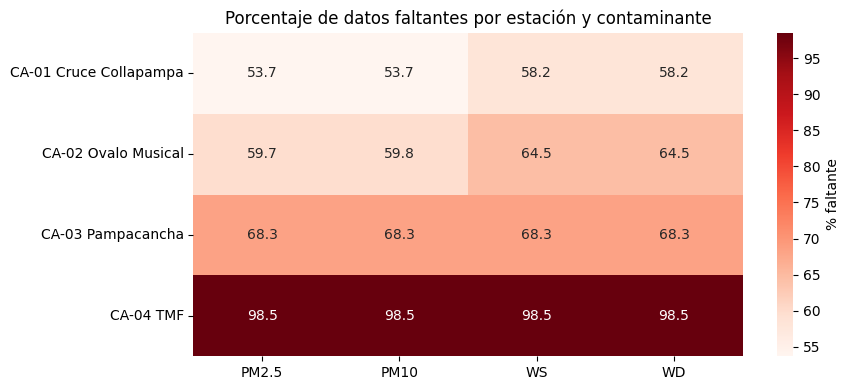

In [ ]:
filas = {}
for est in estaciones:
    filas[est] = {parametro_de(c): round(df[c].isna().mean() * 100, 1)
                  for c in cols_medicion if estacion_de(c) == est}
matriz_faltantes = pd.DataFrame(filas).T
print("% de datos FALTANTES por estación y contaminante:")
display(matriz_faltantes)

plt.figure(figsize=(9, 4))
sns.heatmap(matriz_faltantes, annot=True, fmt=".1f", cmap="Reds",
            cbar_kws={"label": "% faltante"})
plt.title("Porcentaje de datos faltantes por estación y contaminante")
plt.tight_layout(); plt.show()

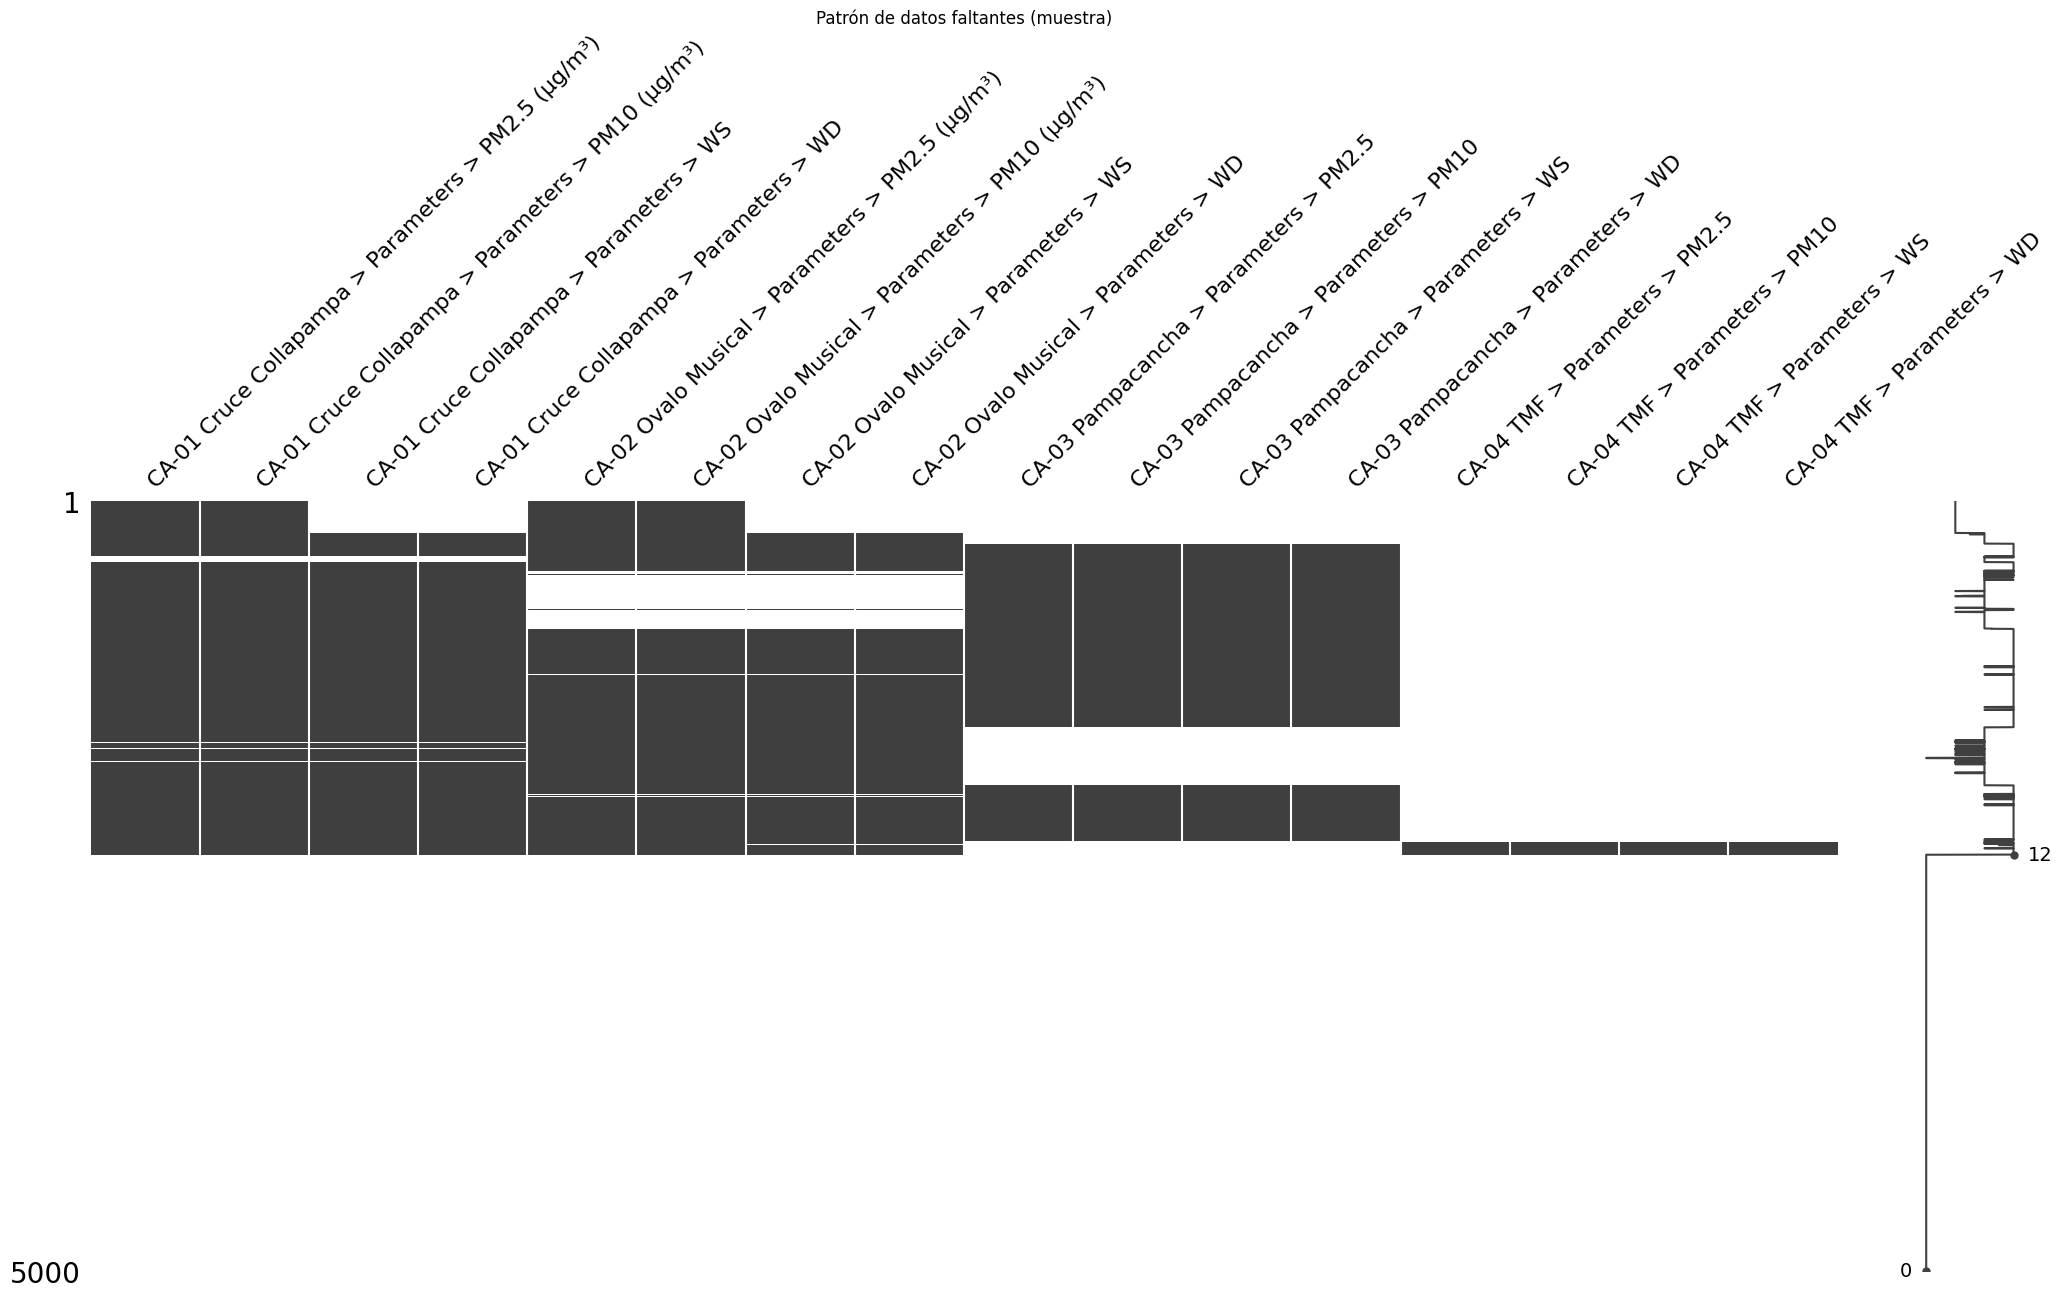

In [ ]:
# Patrón visual de faltantes (muestra de 5000 filas para que sea legible)
muestra = df[cols_medicion].sample(min(5000, len(df))).sort_index()
msno.matrix(muestra)
plt.title("Patrón de datos faltantes (muestra)"); plt.show()

## 7. Reconstrucción de la marca temporal
**Punto crítico:** la columna `Hora` suele venir como **fracción del día** guardada
como **texto con coma decimal** (p. ej. `"0,4201"` = 10:05 a. m.). Si se lee como
hora de reloj, falla y todo cae a medianoche. La función la lee como número.

In [ ]:
# --- Diagnóstico: ¿cómo vienen realmente 'Marca' y 'Hora'? ---
for col in ["Marca", "Hora"]:
    if col in df.columns:
        print(f"{col}: dtype={df[col].dtype} | ejemplos={df[col].dropna().head(4).tolist()}")
print()

def reconstruir_fecha_hora(df, col_fecha="Marca", col_hora="Hora"):
    # Reconstrucción robusta de fecha + hora.
    # La HORA puede venir como fracción de día en TEXTO con coma decimal ('0,4201');
    # por eso se intenta leer como NÚMERO antes que como hora de reloj.
    if col_fecha not in df.columns:
        print("No se encontró la columna de fecha; ajusta 'col_fecha'.")
        return pd.Series(pd.NaT, index=df.index)

    # --- FECHA (solo el día) ---
    f = df[col_fecha]
    fnum = pd.to_numeric(f.astype(str).str.replace(",", ".", regex=False), errors="coerce")
    if pd.api.types.is_numeric_dtype(f) or fnum.notna().mean() > 0.5:   # serial de Excel
        fecha = pd.Timestamp("1899-12-30") + pd.to_timedelta(np.floor(fnum), unit="D")
    else:                                                               # fecha como texto
        fecha = pd.to_datetime(f.astype(str).str.strip(), errors="coerce", dayfirst=True).dt.normalize()

    # --- HORA (desfase dentro del día) ---
    desfase = pd.to_timedelta(0, unit="h")
    if col_hora in df.columns:
        h = df[col_hora]
        hnum = pd.to_numeric(h.astype(str).str.replace(",", ".", regex=False), errors="coerce")
        if hnum.notna().mean() > 0.5:                 # viene como número
            if hnum.max() <= 1.5:                     # fracción de día (0-1) -> caso típico
                desfase = pd.to_timedelta(hnum.fillna(0) * 24, unit="h")
            elif hnum.max() <= 24:                    # horas enteras
                desfase = pd.to_timedelta(hnum.fillna(0), unit="h")
        else:                                         # viene como texto de hora
            ht = pd.to_datetime(h.astype(str).str.strip(), errors="coerce")
            desfase = (pd.to_timedelta(ht.dt.hour.fillna(0), unit="h")
                       + pd.to_timedelta(ht.dt.minute.fillna(0), unit="m"))
    return fecha + desfase

df["fecha_hora"] = reconstruir_fecha_hora(df)
print("Rango temporal :", df["fecha_hora"].min(), "->", df["fecha_hora"].max())
print("Fechas válidas :", df["fecha_hora"].notna().sum(), "de", len(df))

# VERIFICACIÓN: deben aparecer MUCHAS marcas únicas y variedad de horas.
# Si casi todo cae a medianoche y hay millones de duplicados, la hora NO se
# reconstruyó: revisa los ejemplos de la columna 'Hora' (celda de diagnóstico).
print("Marcas únicas  :", df["fecha_hora"].nunique(), "de", len(df))
print("Duplicados     :", int(df["fecha_hora"].duplicated().sum()))
print("Horas distintas:", df["fecha_hora"].dt.hour.nunique(), "(idealmente 24)")

Marca: dtype=object | ejemplos=['25-Jul-22', '26-Jul-22', '1-Jan-22', '1-Jan-22']
Hora: dtype=object | ejemplos=['10:05:00', '22:30:00', '00:00:00', '00:05:00']

Rango temporal : 2022-01-01 00:00:00 -> 2026-06-15 08:45:00
Fechas válidas : 468145 de 978777
Marcas únicas  : 466040 de 978777
Duplicados     : 512736
Horas distintas: 24 (idealmente 24)


## 8. Diagnóstico de integridad (antes de limpiar)
Se reporta **antes** de eliminar nada, para que quede constancia de qué se
encontró y cuánto se descartó en el siguiente paso.

In [ ]:
print("=" * 60)
print("DIAGNÓSTICO DE INTEGRIDAD")
print("=" * 60)

# 1) Fechas con año fuera de un rango razonable
anios = df["fecha_hora"].dt.year
fuera = int(((anios < 2020) | (anios > 2027)).sum())
print(f"1) Fechas con año fuera de 2020-2027 (posible error): {fuera}")

# 2) Valores físicamente imposibles
print("2) Valores físicamente imposibles:")
for c in cols_medicion:
    s = df[c].dropna()
    if s.empty:
        continue
    p, probl = parametro_de(c), []
    if (s < 0).any():
        probl.append(f"{int((s < 0).sum())} negativos")
    if p == "WD" and (s > 360).any():
        probl.append(f"{int((s > 360).sum())} con dirección >360°")
    if p in ("PM2.5", "PM10") and (s > 1000).any():
        probl.append(f"{int((s > 1000).sum())} >1000 µg/m³")
    if probl:
        print(f"   - {estacion_de(c)} {p}: " + ", ".join(probl))

# 3) Inconsistencia física PM2.5 > PM10 (PM2.5 es subconjunto de PM10)
print("3) Inconsistencias PM2.5 > PM10:")
for est in estaciones:
    c25 = [c for c in cols_medicion if estacion_de(c) == est and parametro_de(c) == "PM2.5"]
    c10 = [c for c in cols_medicion if estacion_de(c) == est and parametro_de(c) == "PM10"]
    if c25 and c10:
        m = df[c25[0]].notna() & df[c10[0]].notna()
        viol = int((df.loc[m, c25[0]] > df.loc[m, c10[0]]).sum())
        if viol:
            print(f"   - {est}: {viol} registros")

DIAGNÓSTICO DE INTEGRIDAD
1) Fechas con año fuera de 2020-2027 (posible error): 0
2) Valores físicamente imposibles:
   - CA-01 Cruce Collapampa PM10: 1199 >1000 µg/m³
   - CA-01 Cruce Collapampa WD: 1 con dirección >360°
   - CA-02 Ovalo Musical PM10: 2270 >1000 µg/m³
   - CA-02 Ovalo Musical WD: 43 con dirección >360°
   - CA-03 Pampacancha PM2.5: 1 negativos
   - CA-03 Pampacancha PM10: 113 >1000 µg/m³
   - CA-04 TMF PM10: 3 >1000 µg/m³
3) Inconsistencias PM2.5 > PM10:
   - CA-01 Cruce Collapampa: 1 registros
   - CA-02 Ovalo Musical: 2018 registros
   - CA-03 Pampacancha: 121 registros


## 9. Limpieza: duplicados, fechas corruptas y errores físicos
Se descartan filas sin fecha válida o con año fuera de rango, se eliminan
duplicados por marca temporal y se corrigen errores físicos:
- Dirección de viento (`WD`) fuera de 0–360° → vacío
- Valores negativos en PM2.5, PM10, PM1, PM100 y WS → vacío
- `PM2.5 > PM10` → se **marca** con una columna de bandera (no se borra, por
  si es señal de un evento real)

*(Nota de la fusión: aquí se incluye la limpieza de negativos para **PM1** y
**PM100** además de PM2.5/PM10/WS.

In [ ]:
n0 = len(df)
df = df[df["fecha_hora"].notna()]                                   # sin fecha -> fuera
df = df[df["fecha_hora"].dt.year.between(2020, 2027)]              # años corruptos -> fuera
df = (df.drop_duplicates(subset="fecha_hora")
        .sort_values("fecha_hora")
        .reset_index(drop=True))
print(f"Filas: {n0:,} -> {len(df):,} "
      f"(se quitaron {n0 - len(df):,} por fecha nula/corrupta/duplicada)")

for c in cols_medicion:
    p = parametro_de(c)
    if p == "WD":
        df.loc[(df[c] < 0) | (df[c] > 360), c] = np.nan
    if p in ("PM2.5", "PM10", "PM1", "PM100", "WS"):
        df.loc[df[c] < 0, c] = np.nan

for est in estaciones:
    c25 = [c for c in cols_medicion if estacion_de(c) == est and parametro_de(c) == "PM2.5"]
    c10 = [c for c in cols_medicion if estacion_de(c) == est and parametro_de(c) == "PM10"]
    if c25 and c10:
        df[f"flag_PM25gtPM10__{est}"] = (df[c25[0]] > df[c10[0]])
print("Errores físicos tratados (WD y negativos -> vacío; PM2.5>PM10 marcado)")

Filas: 978,777 -> 466,040 (se quitaron 512,737 por fecha nula/corrupta/duplicada)
Errores físicos tratados (WD y negativos -> vacío; PM2.5>PM10 marcado)


## 10. Resumen, carga y limpieza (5 min)

In [ ]:
print("RESUMEN — CARGA Y LIMPIEZA (5 min)")
print("-" * 45)
print(f"Filas        : {len(df):,}")
print(f"Columnas     : {df.shape[1]}")
print(f"Estaciones   : {len(estaciones)} -> {estaciones}")
print(f"Parámetros   : {parametros}")
print(f"Rango        : {df['fecha_hora'].min()}  a  {df['fecha_hora'].max()}")

RESUMEN — CARGA Y LIMPIEZA (5 min)
---------------------------------------------
Filas        : 466,040
Columnas     : 31
Estaciones   : 4 -> ['CA-01 Cruce Collapampa', 'CA-02 Ovalo Musical', 'CA-03 Pampacancha', 'CA-04 TMF']
Parámetros   : ['PM10', 'PM2.5', 'WD', 'WS']
Rango        : 2022-01-01 00:00:00  a  2026-06-15 08:45:00


## 11. Reestructuración a formato largo (tidy)
Una fila por **estación - contaminante - tiempo**. Es el formato ideal para
graficar y para alimentar modelos. Se conserva el turno (`Tipo`: Diurno/Nocturno)
si existe en el archivo.

In [ ]:
piezas = []
for c in cols_medicion:
    tmp = df[["fecha_hora", c]].copy()
    tmp.columns = ["fecha_hora", "valor"]
    tmp["estacion"]     = estacion_de(c)
    tmp["contaminante"] = parametro_de(c)
    piezas.append(tmp)
largo = pd.concat(piezas, ignore_index=True)

if "Tipo" in df.columns:
    largo = largo.merge(df[["fecha_hora", "Tipo"]].rename(columns={"Tipo": "turno"}),
                        on="fecha_hora", how="left")
print("Formato largo:", largo.shape)
largo.head()

Formato largo: (7456640, 5)


,fecha_hora,valor,estacion,contaminante,turno
0,2022-01-01 00:00:00,1.8,CA-01 Cruce Collapampa,PM2.5,Nocturno
1,2022-01-01 00:05:00,1.7,CA-01 Cruce Collapampa,PM2.5,Nocturno
2,2022-01-01 00:10:00,1.9,CA-01 Cruce Collapampa,PM2.5,Nocturno
3,2022-01-01 00:15:00,2.8,CA-01 Cruce Collapampa,PM2.5,Nocturno
4,2022-01-01 00:20:00,2.4,CA-01 Cruce Collapampa,PM2.5,Nocturno


## 12. Regularización a una rejilla uniforme de 5 minutos
La frecuencia original ya es de **5 minutos**. Aquí **no** promediamos a nada:
solo alineamos los tiempos a una rejilla uniforme de 5 min para que cada caída
del sensor quede **explícita** como una fila `NaN`.

> solo se consideran los **límites internos**, se pasa directo de los datos de 5 min
> limpios a la imputación, sin agregar nada.

Esta tabla de 5 min (`datos_5m`) es la que reutilizan la red / imputación y el
modelado más abajo.


In [ ]:
PASO_MIN = 5                 # resolución nativa del sensor, en minutos
POR_HORA = 60 // PASO_MIN     # 12 muestras de 5 min por hora
FREQ     = f"{PASO_MIN}min"

# Tabla ancha: índice = tiempo, columnas = (estación, contaminante)
ancho = largo.pivot_table(index="fecha_hora",
                          columns=["estacion", "contaminante"],
                          values="valor", aggfunc="mean")

# Regularizar a una rejilla UNIFORME de 5 min. Esto NO es una agregación: la
# resolución nativa ya es de 5 min; solo alinea los tiempos a la rejilla y hace
# EXPLÍCITO cada hueco del sensor como una fila NaN (necesario para imputar bien).
datos_5m = ancho.resample(FREQ).mean()

print("Dataset 5 min:", datos_5m.shape)
print(f"% faltante global (5 min): {datos_5m.isna().mean().mean() * 100:.1f}%")

# Diagnóstico: pasos de 5 min esperados en el rango vs. filas presentes
n_esperado = int((datos_5m.index.max() - datos_5m.index.min()) / pd.Timedelta(FREQ)) + 1
print(f"Pasos de 5 min en el rango: {n_esperado:,} | filas en la tabla: {len(datos_5m):,}")
datos_5m.head()


Dataset 5 min: (468394, 16)
% faltante global (5 min): 40.2%
Pasos de 5 min en el rango: 468,394 | filas en la tabla: 468,394


estacion            CA-01 Cruce Collapampa               CA-02 Ovalo Musical  \
contaminante                          PM10 PM2.5  WD  WS                PM10   
fecha_hora                                                                     
2022-01-01 00:00:00                    4.0   1.8 NaN NaN                 6.9   
2022-01-01 00:05:00                    3.9   1.7 NaN NaN                 5.8   
2022-01-01 00:10:00                    4.4   1.9 NaN NaN                 3.9   
2022-01-01 00:15:00                    6.2   2.8 NaN NaN                 5.3   
2022-01-01 00:20:00                    4.1   2.4 NaN NaN                 5.0   

estacion                          CA-03 Pampacancha               CA-04 TMF  \
contaminante        PM2.5  WD  WS              PM10 PM2.5  WD  WS      PM10   
fecha_hora                                                                    
2022-01-01 00:00:00   2.5 NaN NaN               NaN   NaN NaN NaN       NaN   
2022-01-01 00:05:00   2.3 NaN NaN               NaN   NaN NaN NaN       NaN   
2022-01-01 00:10:00   1.6 NaN NaN               NaN   NaN NaN NaN       NaN   
2022-01-01 00:15:00   2.0 NaN NaN               NaN   NaN NaN NaN       NaN   
2022-01-01 00:20:00   2.0 NaN NaN               NaN   NaN NaN NaN       NaN   

estacion                           
contaminante        PM2.5  WD  WS  
fecha_hora                         
2022-01-01 00:00:00   NaN NaN NaN  
2022-01-01 00:05:00   NaN NaN NaN  
2022-01-01 00:10:00   NaN NaN NaN  
2022-01-01 00:15:00   NaN NaN NaN  
2022-01-01 00:20:00   NaN NaN NaN

## 13. Guardado del dataset de 5 minutos (limpio, sin imputar)


In [ ]:
# En /content (descargable). Para Drive, descomenta el bloque de abajo.
datos_5m.to_parquet("constancia_5min_rejilla.parquet")
df.to_parquet("constancia_5min_limpio.parquet")
print("Guardados:")
print("  - constancia_5min_rejilla.parquet  (rejilla uniforme 5 min, SIN imputar)")
print("  - constancia_5min_limpio.parquet   (5 min, limpio, columnas originales)")

# --- Copiar a tu Drive ---
# from google.colab import drive; drive.mount("/content/drive")
# datos_5m.to_parquet("/content/drive/MyDrive/constancia_5min_rejilla.parquet")


Guardados:
  - constancia_5min_rejilla.parquet  (rejilla uniforme 5 min, SIN imputar)
  - constancia_5min_limpio.parquet   (5 min, limpio, columnas originales)


## 14. Red de monitoreo: ¿cambió en el tiempo? (altas y bajas de estaciones)
En minería los puntos de monitoreo cambian: algunos tajos cierran y se instalan
nuevos. Aquí vemos **cuándo empieza y termina** el dato de cada estación. La clave
es la **cobertura dentro de su ventana operativa**, no sobre todo el periodo.

In [ ]:
act = pd.DataFrame(index=df["fecha_hora"])
for est in estaciones:
    cols_est = [c for c in cols_medicion if estacion_de(c) == est]
    act[est] = df[cols_est].notna().any(axis=1).values

glob_ini, glob_fin = df["fecha_hora"].min(), df["fecha_hora"].max()
print("PERIODO OPERATIVO POR ESTACIÓN")
print("-" * 78)
meta = []
for est in estaciones:
    ok = act.index[act[est]]
    if len(ok):
        alta, baja = ok.min(), ok.max()
        en_ventana = act.loc[(act.index >= alta) & (act.index <= baja), est]
        cob_ventana = en_ventana.mean() * 100          # cobertura DENTRO de su ventana
        meta.append(dict(estacion=est, fecha_alta=alta, fecha_baja=baja,
                         meses=round((baja - alta).days / 30.4, 1),
                         cobertura_ventana=round(cob_ventana, 1)))
        print(f"{est:24s} {alta:%Y-%m-%d} -> {baja:%Y-%m-%d} | "
              f"{(baja-alta).days/30.4:5.1f} meses | cobertura en ventana: {cob_ventana:5.1f}%")
    else:
        print(f"{est:24s} SIN DATOS")

PERIODO OPERATIVO POR ESTACIÓN
------------------------------------------------------------------------------
CA-01 Cruce Collapampa   2022-01-01 -> 2026-06-15 |  53.5 meses | cobertura en ventana:  96.8%
CA-02 Ovalo Musical      2022-01-01 -> 2026-06-15 |  53.5 meses | cobertura en ventana:  84.3%
CA-03 Pampacancha        2022-07-23 -> 2026-04-12 |  44.7 meses | cobertura en ventana:  79.3%
CA-04 TMF                2026-04-26 -> 2026-06-15 |   1.6 meses | cobertura en ventana:  99.2%


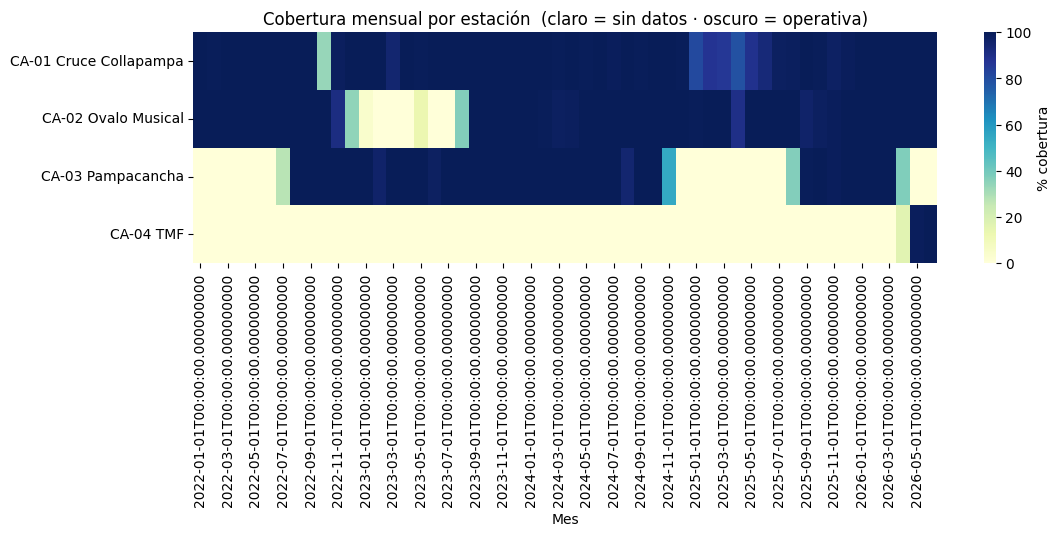

In [ ]:
# Mapa de cobertura mensual: claro = sin datos, oscuro = operativa
cob = act.resample("MS").mean().mul(100)
plt.figure(figsize=(12, 3))
sns.heatmap(cob.T, cmap="YlGnBu", vmin=0, vmax=100, cbar_kws={"label": "% cobertura"})
plt.title("Cobertura mensual por estación  (claro = sin datos · oscuro = operativa)")
plt.xlabel("Mes"); plt.ylabel(""); plt.tight_layout(); plt.show()

**Cómo leerlo:** si una estación está *clara al inicio y oscura solo al final*,
es **nueva**. Si está *oscura al inicio y se apaga al final*, **dejó de operar**.
Si está oscura con manchas claras dispersas, son **fallas intermitentes** normales.

## 15. Tabla de metadatos y decisión automática de estaciones para el modelo
Distinguimos una estación **nueva con buenos datos** (se conserva) de una
**defectuosa** (se descarta). El criterio es la **cobertura dentro de su
ventana**, no el % total — así una estación nueva no se castiga por su corta
historia.

`estaciones_modelo` es la lista que se usará **de aquí en adelante** —
incluyendo el feature engineering y ambos modelos (Secciones 17 y 18)

In [ ]:
meta = pd.DataFrame(meta)
margen = pd.Timedelta(days=45)

def clasificar(r):
    nueva  = r["fecha_alta"] > glob_ini + pd.Timedelta(days=120)
    cesada = r["fecha_baja"] < glob_fin - margen
    if   cesada and nueva: return "TEMPORAL"
    elif cesada:           return "DEJÓ DE OPERAR"
    elif nueva:            return "NUEVA (activa)"
    else:                  return "CONTINUA"

meta["estado"] = meta.apply(clasificar, axis=1)

UMBRAL_COB = 50   # % mínimo de cobertura DENTRO de la ventana para ser utilizable
meta["en_modelo"]     = np.where(meta["cobertura_ventana"] >= UMBRAL_COB,
                                 "INCLUIR", "EXCLUIR (datos escasos)")
meta["alerta_en_vivo"] = np.where(meta["estado"] == "DEJÓ DE OPERAR",
                                  "No (sin dato actual)", "Sí")
display(meta)

estaciones_modelo = meta.loc[meta["en_modelo"] == "INCLUIR", "estacion"].tolist()
print("\nEstaciones que ENTRAN al modelado:", estaciones_modelo)
print("(Las excluidas siguen sirviendo para analizar su periodo activo, no para el modelo.)")

,estacion,fecha_alta,fecha_baja,meses,cobertura_ventana,estado,en_modelo,alerta_en_vivo
0,CA-01 Cruce Collapampa,2022-01-01 00:00:00,2026-06-15 08:45:00,53.5,96.8,CONTINUA,INCLUIR,Sí
1,CA-02 Ovalo Musical,2022-01-01 00:00:00,2026-06-15 08:45:00,53.5,84.3,CONTINUA,INCLUIR,Sí
2,CA-03 Pampacancha,2022-07-23 10:35:00,2026-04-12 09:20:00,44.7,79.3,TEMPORAL,INCLUIR,Sí
3,CA-04 TMF,2026-04-26 00:00:00,2026-06-15 08:45:00,1.6,99.2,NUEVA (activa),INCLUIR,Sí



Estaciones que ENTRAN al modelado: ['CA-01 Cruce Collapampa', 'CA-02 Ovalo Musical', 'CA-03 Pampacancha', 'CA-04 TMF']
(Las excluidas siguen sirviendo para analizar su periodo activo, no para el modelo.)


## 16. Imputación de huecos cortos (medida por duración real)
Generamos dos versiones:
- **Sin imputar** (`datos_5m_valida`) — la señal cruda de 5 min de las estaciones válidas.
- **Con huecos cortos imputados** + bandera `faltante` — para el modelo.


La imputación usa `limit_area="inside"`, así **no inventa** datos fuera de la
ventana operativa de cada estación.


In [ ]:
MAX_HUECO_MIN = 30   # minutos: se rellenan SOLO huecos cuya duración total <= esto.
                     # A 5 min conviene revisarlo (ver diagnóstico de la celda siguiente):
                     # 15 min ~ hasta 2 muestras seguidas; 30 min ~ hasta 5 muestras.

def imputar_huecos_cortos(serie, max_min=MAX_HUECO_MIN):
    # Interpola por TIEMPO REAL (agnóstico a la frecuencia) y restaura los huecos
    # largos comparando su DURACIÓN en minutos —no el número de filas—, así funciona
    # igual a 5 min, horario o cualquier otra frecuencia.
    s = serie.copy()
    lleno = s.interpolate(method="time", limit_area="inside")

    valido = s.notna()
    ts = pd.Series(s.index, index=s.index)     # marca temporal de cada fila
    t_prev = ts.where(valido).ffill()          # tiempo del último dato válido anterior
    t_next = ts.where(valido).bfill()          # tiempo del próximo dato válido posterior
    # duración del hueco que rodea a cada NaN = span entre los válidos que lo bordean
    dur_min = (t_next - t_prev).dt.total_seconds() / 60.0

    lleno[s.isna() & (dur_min > max_min)] = np.nan     # restaura los huecos largos
    return lleno

datos_5m_valida = datos_5m[estaciones_modelo]          # solo estaciones con cobertura suficiente
faltante        = datos_5m_valida.isna()               # dónde había hueco real
datos_5m_imp    = datos_5m_valida.apply(imputar_huecos_cortos)
glob_fin        = datos_5m_imp.index.max()

print("5 min (sin imputar, estaciones válidas):", datos_5m_valida.shape,
      "| faltante:", round(datos_5m_valida.isna().mean().mean() * 100, 1), "%")
print(f"5 min (imputado, huecos <= {MAX_HUECO_MIN} min):", datos_5m_imp.shape,
      "| faltante:", round(datos_5m_imp.isna().mean().mean() * 100, 1), "%")


5 min (sin imputar, estaciones válidas): (468394, 16) | faltante: 40.2 %
5 min (imputado, huecos <= 30 min): (468394, 16) | faltante: 40.1 %


Longitud de huecos (min) — percentiles:
count       4194.0
mean        3588.1
std        72379.4
min            5.0
50%            5.0
75%           60.0
90%          440.0
95%          720.0
99%         3993.3
max      2269440.0
dtype: float64
  Huecos <=   5 min:  66.8% de los bloques  (SE IMPUTAN)
  Huecos <=  10 min:  69.6% de los bloques  (SE IMPUTAN)
  Huecos <=  15 min:  71.1% de los bloques  (SE IMPUTAN)
  Huecos <=  30 min:  72.8% de los bloques  (SE IMPUTAN)
  Huecos <=  60 min:  75.6% de los bloques  (se dejan como NaN)
  Huecos <= 120 min:  76.9% de los bloques  (se dejan como NaN)


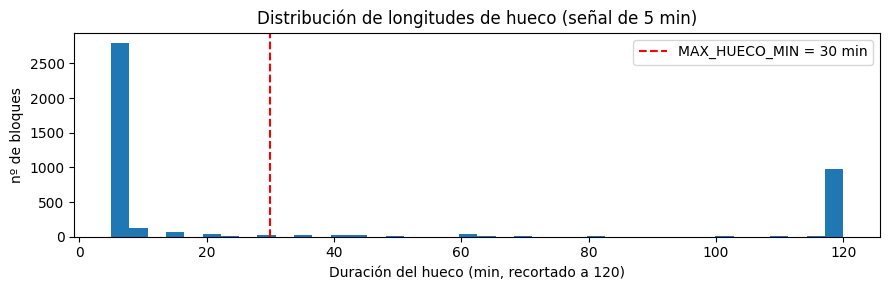

In [ ]:
# --- Diagnóstico: distribución de longitudes de hueco (punto 3) ---
# Ayuda a decidir MAX_HUECO_MIN. Mide, por columna, la duración (en min) de cada
# bloque de NaN consecutivos de la señal cruda de 5 min.
def longitudes_de_huecos_min(serie):
    es_nan = serie.isna()
    bloque = (es_nan != es_nan.shift()).cumsum()
    tam = es_nan.groupby(bloque).sum()          # nº de muestras NaN por bloque
    tam = tam[tam > 0]
    return (tam * PASO_MIN).astype(float)       # duración del bloque en minutos

todas = pd.concat([longitudes_de_huecos_min(datos_5m_valida[c]) for c in datos_5m_valida.columns])
if len(todas):
    print("Longitud de huecos (min) — percentiles:")
    print(todas.describe(percentiles=[.5, .75, .9, .95, .99]).round(1))
    for u in [5, 10, 15, 30, 60, 120]:
        pct = (todas <= u).mean() * 100
        print(f"  Huecos <= {u:>3d} min: {pct:5.1f}% de los bloques  "
              f"({'SE IMPUTAN' if u <= MAX_HUECO_MIN else 'se dejan como NaN'})")
    plt.figure(figsize=(9, 3))
    plt.hist(todas.clip(upper=120), bins=40)
    plt.axvline(MAX_HUECO_MIN, color="red", ls="--", label=f"MAX_HUECO_MIN = {MAX_HUECO_MIN} min")
    plt.xlabel("Duración del hueco (min, recortado a 120)"); plt.ylabel("nº de bloques")
    plt.title("Distribución de longitudes de hueco (señal de 5 min)")
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print("No se detectaron huecos en las estaciones válidas.")


## 2. Radiografía de las emisiones: Excedencias y Estacionalidad

El problema del polvo se hace más evidente bajo ciertas condiciones. Aquí analizaremos visualmente cómo la temporada seca (periodo de escasez de lluvias en Cusco), donde la humedad del terreno es mínima, dispara las alertas de riego.

A través del **Índice de Excedencia de Límites Internos** y el **Factor de Estacionalidad**, cuantificaremos la magnitud del problema enfocándonos en las temporadas y las horas críticas del día.

## 17. Análisis exploratorio para los indicadores
Todo lo que sigue usa `datos_5m_imp` (estaciones válidas, huecos cortos
imputados).

### 17.1 Perfil horario — ¿a qué hora suben los picos de polvo?

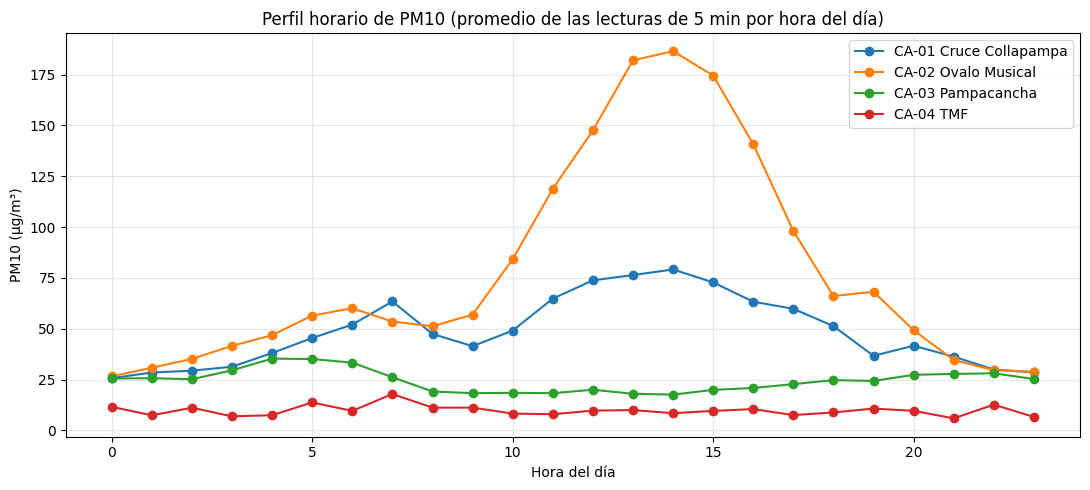

In [ ]:
pm10_cols = [c for c in datos_5m_imp.columns if c[1] == "PM10"]
perfil = datos_5m_imp[pm10_cols].groupby(datos_5m_imp.index.hour).mean()
perfil.columns = [c[0] for c in perfil.columns]
perfil.plot(marker="o")
plt.title("Perfil horario de PM10 (promedio de las lecturas de 5 min por hora del día)")
plt.xlabel("Hora del día"); plt.ylabel("PM10 (µg/m³)")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()


### 17.2 Estacionalidad — temporada seca (May–Oct) vs. lluvia
Incluye prueba estadística (Mann–Whitney) para demostrar que la diferencia
**no es azar**, y la razón seca/lluvia.

                  mean  median   count
temporada                             
Lluvia (Nov-Abr)  32.5     6.2  241170
Seca (May-Oct)    71.5    42.2  224014

Mann-Whitney: p = 0.00e+00  ->  diferencia SIGNIFICATIVA
Razón seca/lluvia (medianas): 6.80x


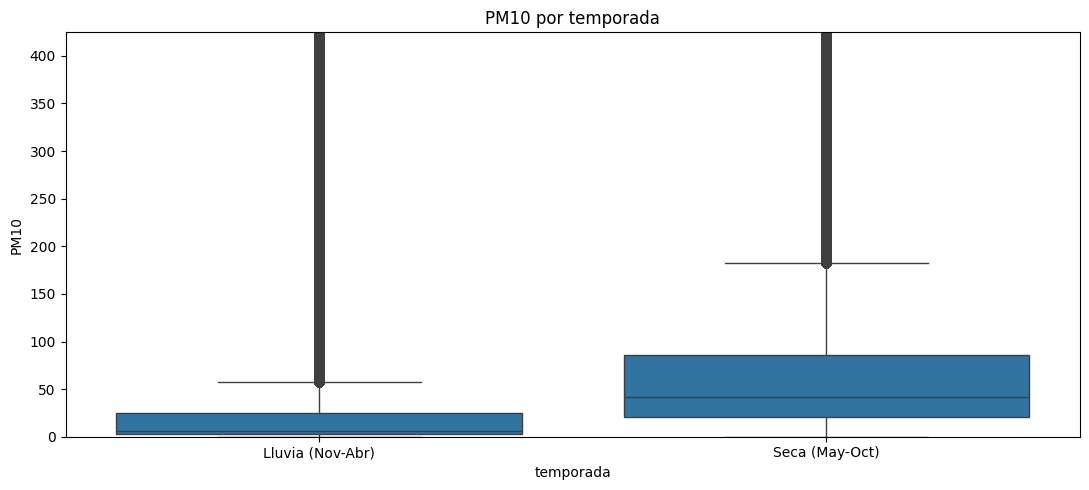

In [ ]:
from scipy import stats
mes       = datos_5m_imp.index.month
temporada = np.where((mes >= 5) & (mes <= 10), "Seca (May-Oct)", "Lluvia (Nov-Abr)")
pm10_prom = datos_5m_imp[pm10_cols].mean(axis=1)

comp = pd.DataFrame({"PM10": pm10_prom.values, "temporada": temporada}).dropna()
print(comp.groupby("temporada")["PM10"].agg(["mean", "median", "count"]).round(1))

seca   = comp.loc[comp.temporada.str.startswith("Seca"),   "PM10"]
lluvia = comp.loc[comp.temporada.str.startswith("Lluvia"), "PM10"]
u, p = stats.mannwhitneyu(seca, lluvia)
print(f"\nMann-Whitney: p = {p:.2e}  ->  "
      f"{'diferencia SIGNIFICATIVA' if p < 0.05 else 'no significativa'}")
print(f"Razón seca/lluvia (medianas): {seca.median() / lluvia.median():.2f}x")

sns.boxplot(data=comp, x="temporada", y="PM10")
plt.ylim(0, comp.PM10.quantile(.99)); plt.title("PM10 por temporada")
plt.tight_layout(); plt.show()


### 17.3 Matriz temporada × turno (día/noche)

In [ ]:
hora  = datos_5m_imp.index.hour
turno = np.where((hora >= 7) & (hora < 19), "Día", "Noche")   # ajusta a tu turno real
matriz = pd.DataFrame({"PM10": pm10_prom.values, "temporada": temporada,
                       "turno": turno}).dropna()
tabla_turno = matriz.pivot_table(values="PM10", index="temporada", columns="turno", aggfunc="median")
print("PM10 mediana por temporada × turno:")
display(tabla_turno.round(1))


PM10 mediana por temporada × turno:


turno,Día,Noche
temporada,,
Lluvia (Nov-Abr),8.0,5.3
Seca (May-Oct),55.7,33.7


## 3. El factor viento: Índice de Aporte Direccional

No basta con medir la concentración de polvo; necesitamos evidenciar su procedencia. En esta sección calcularemos el **Índice de Aporte Direccional** cruzando los eventos altos de PM10 y PM2.5 con la dirección predominante del viento. Esto nos permitirá cuantificar qué porcentaje de los picos realmente provienen del rumbo de la vía de acarreo, descartando fuentes ajenas a nuestra gestión.

### 17.4 Rosa de contaminación — ¿de qué dirección llega el polvo?
Cruza PM10 con la dirección del viento. Si los pétalos más altos apuntan hacia
la **vía de acarreo**, es la evidencia de que esa es la fuente.

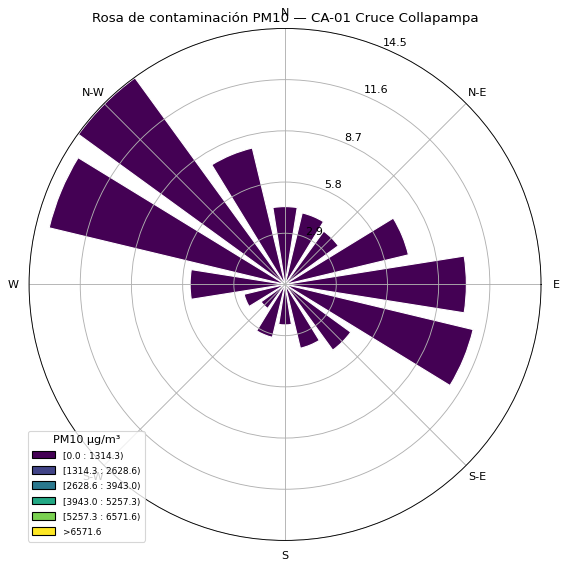

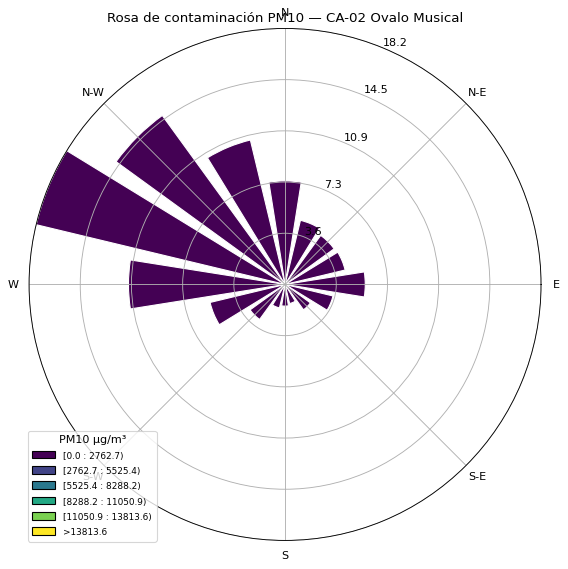

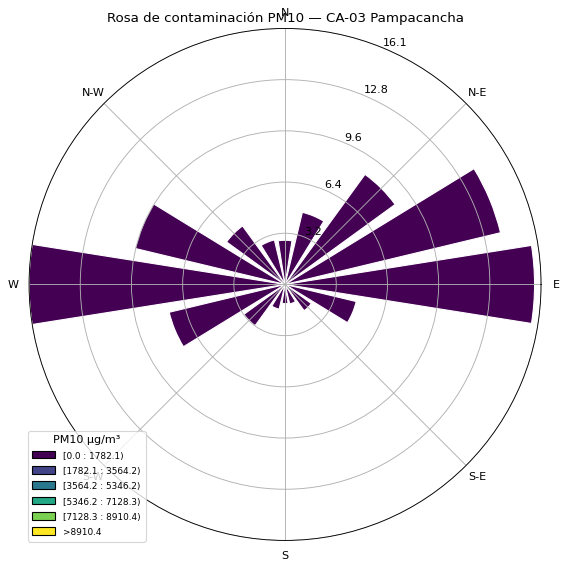

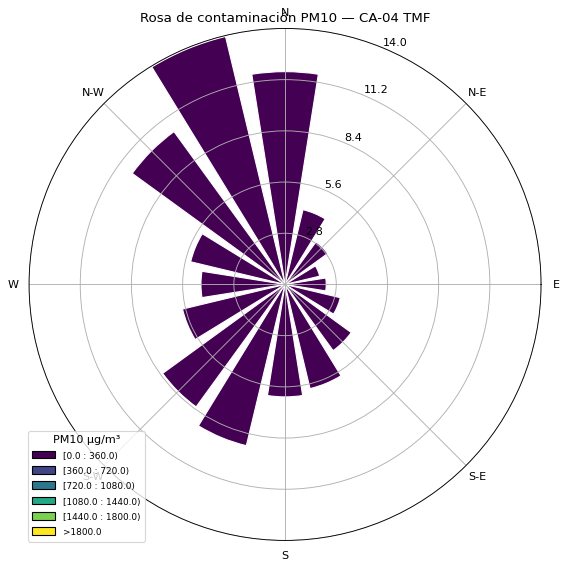

In [ ]:
from windrose import WindroseAxes
cols_mod = [c for c in cols_medicion if estacion_de(c) in estaciones_modelo]
for est in estaciones_modelo:
    wd_c = [c for c in cols_mod if estacion_de(c) == est and parametro_de(c) == "WD"]
    pm_c = [c for c in cols_mod if estacion_de(c) == est and parametro_de(c) == "PM10"]
    if not (wd_c and pm_c):
        continue
    d = df[["fecha_hora", wd_c[0], pm_c[0]]].dropna()
    if len(d) < 100:
        print(f"{est}: datos insuficientes para la rosa"); continue
    ax = WindroseAxes.from_ax()
    ax.bar(d[wd_c[0]].values, d[pm_c[0]].values,
           normed=True, opening=0.8, edgecolor="white", nsector=16)
    ax.set_legend(title="PM10 µg/m³", loc="lower left")
    plt.title(f"Rosa de contaminación PM10 — {est}")
    plt.show()

### 17.5 Mapa interactivo y vistas por estación (Plotly)
Tres vistas interactivas con un menú desplegable para alternar entre PM10 y
PM2.5:
- **Mapa**: ubicación real de las estaciones, con las coordenadas leídas de
  los KMZ que compartiste (`CA-01_Cruce_Collapampa`, `CA-02_Ovalo_Musical`,
  `CA-03_Pampacancha`), coloreada por el promedio histórico del contaminante.
- **Boxplot**: distribución diaria por estación (¿cuál es más ruidosa o tiene
  más picos?).
- **Perfil horario**: promedio por hora del día (0–23h), para ver a qué hora
  sube el polvo en cada estación.

`CA-04 TMF` no tiene KMZ entre los archivos que compartiste, así que **no
aparece en el mapa** (sí aparece en el boxplot y el perfil horario, que no
necesitan coordenadas).

In [ ]:
import glob, zipfile
import xml.etree.ElementTree as ET
import plotly.graph_objects as go

POLUTANTS = ["PM10", "PM2.5"]
POLUTANT_LABELS = {"PM10": "PM10 (µg/m³)", "PM2.5": "PM2.5 (µg/m³)"}

# Coordenadas ya extraidas de los KMZ que compartiste (sirven de respaldo si no
# subes los .kmz a esta sesion de Colab).
COORDS_KMZ = {
    "CA-01 Cruce Collapampa": (-14.47864963632417, -71.77815368177031),
    "CA-02 Ovalo Musical":    (-14.46775507342458, -71.77216900169483),
    "CA-03 Pampacancha":      (-14.48823771329744, -71.74393522380686),
}

def leer_kmz(path):
    """Nombre + (lat, lon) del primer Placemark de un .kmz (Google Earth)."""
    with zipfile.ZipFile(path) as z:
        kml_name = next(n for n in z.namelist() if n.endswith(".kml"))
        raw = z.read(kml_name)
    ns = {"kml": "http://www.opengis.net/kml/2.2"}
    root = ET.fromstring(raw)
    pm = root.find(".//kml:Placemark", ns)
    nombre = pm.find("kml:name", ns).text.strip()
    coords = pm.find(".//kml:Point/kml:coordinates", ns).text.strip()
    lon, lat, *_ = [float(x) for x in coords.split(",")]
    return nombre, lat, lon

# Si subes los .kmz a la carpeta de Colab, se leen aqui y actualizan COORDS_KMZ
# (asi el notebook usa siempre la fuente mas fresca sin tener que copiar/pegar nada).
for kmz_path in glob.glob("/content/*.kmz") + glob.glob("*.kmz"):
    try:
        nombre, lat, lon = leer_kmz(kmz_path)
        clave = next((e for e in estaciones if e.split()[0] == nombre.split()[0]), nombre)
        COORDS_KMZ[clave] = (lat, lon)
    except Exception as e:
        print(f"No se pudo leer {kmz_path}: {e}")

print("Estaciones con coordenadas:", list(COORDS_KMZ.keys()))

Estaciones con coordenadas: ['CA-01 Cruce Collapampa', 'CA-02 Ovalo Musical', 'CA-03 Pampacancha']


In [ ]:
# Tabla de metadatos para el mapa: coordenadas + promedio historico por contaminante
RANGO_FECHAS = f"{datos_5m_imp.index.min():%Y-%m} a {datos_5m_imp.index.max():%Y-%m}"

filas_meta = []
for est, (lat, lon) in COORDS_KMZ.items():
    if est not in datos_5m_imp.columns.get_level_values(0):
        continue  # sin datos en la tabla de 5 min modelada
    fila = {"ESTACION": est, "LATITUD": lat, "LONGITUD": lon,
            "DISTRITO": "Chamaca, Chumbivilcas (Cusco)"}
    for p in POLUTANTS:
        if p in datos_5m_imp[est].columns:
            fila[f"{p}_mean"] = datos_5m_imp[est][p].mean()
    filas_meta.append(fila)

station_meta = pd.DataFrame(filas_meta)

faltan = set(estaciones_modelo) - set(station_meta["ESTACION"])
if faltan:
    print(f"Sin coordenadas KMZ para: {sorted(faltan)} (no apareceran en el mapa).")

display(station_meta)

Sin coordenadas KMZ para: ['CA-04 TMF'] (no apareceran en el mapa).


,ESTACION,LATITUD,LONGITUD,DISTRITO,PM10_mean,PM2.5_mean
0,CA-01 Cruce Collapampa,-14.478650,-71.778154,"Chamaca, Chumbivilcas (Cusco)",48.835404,3.656967
1,CA-02 Ovalo Musical,-14.467755,-71.772169,"Chamaca, Chumbivilcas (Cusco)",78.280861,4.402406
2,CA-03 Pampacancha,-14.488238,-71.743935,"Chamaca, Chumbivilcas (Cusco)",24.486181,2.958042


In [ ]:
def build_map_figure(station_meta, pollutants):
    fig = go.Figure()
    # Por cada contaminante se agregan 2 trazas: una "de borde" (puntos negros, un poco
    # mas grandes, dibujada primero/debajo) y la traza real coloreada encima. Scattermapbox
    # no soporta marker.line (borde) como si soporta go.Scatter, asi que este es el truco
    # para simular un borde negro alrededor de cada punto.
    for i, p in enumerate(pollutants):
        sizes = station_meta[f'{p}_mean'] / station_meta[f'{p}_mean'].max() * 30 + 12

        fig.add_trace(go.Scattermapbox(
            lat=station_meta['LATITUD'],
            lon=station_meta['LONGITUD'],
            mode='markers',
            marker=dict(size=sizes + 4, color='black'),
            hoverinfo='skip',
            showlegend=False,
            visible=(i == 0),
        ))
        fig.add_trace(go.Scattermapbox(
            lat=station_meta['LATITUD'],
            lon=station_meta['LONGITUD'],
            mode='markers+text',
            marker=dict(
                size=sizes,
                color=station_meta[f'{p}_mean'],
                colorscale='turbo',
                showscale=True,
                colorbar=dict(title=POLUTANT_LABELS[p]),
            ),
            text=station_meta['ESTACION'],
            textposition='top center',
            customdata=station_meta[['DISTRITO', f'{p}_mean']],
            hovertemplate=(
                '<b>%{text}</b><br>Distrito: %{customdata[0]}<br>'
                + POLUTANT_LABELS[p] + ' (promedio historico): %{customdata[1]:.1f}<extra></extra>'
            ),
            visible=(i == 0),
            name=POLUTANT_LABELS[p],
            showlegend=False,  # el colorbar ya indica la escala; el titulo ya indica el contaminante
        ))

    # Menu desplegable: cada boton alterna cual par de trazas (borde + relleno) es visible
    buttons = []
    for i, p in enumerate(pollutants):
        visible = []
        for j in range(len(pollutants)):
            visible.extend([j == i, j == i])  # [borde, relleno] por cada contaminante
        buttons.append(dict(
            label=POLUTANT_LABELS[p],
            method='update',
            args=[{'visible': visible}, {'title': f'Estaciones de monitoreo - {POLUTANT_LABELS[p]} (promedio {RANGO_FECHAS})'}],
        ))

    # style='open-street-map' no requiere token de Mapbox
    fig.update_layout(
        mapbox=dict(
            style='open-street-map',
            center=dict(lat=station_meta['LATITUD'].mean(), lon=station_meta['LONGITUD'].mean()),
            zoom=13,
        ),
        updatemenus=[dict(
            active=0, buttons=buttons, x=0.01, y=0.99, xanchor='left', yanchor='top',
        )],
        title=f'Estaciones de monitoreo - {POLUTANT_LABELS[pollutants[0]]} (promedio {RANGO_FECHAS})',
        margin=dict(l=0, r=0, t=40, b=0),
        height=420,
    )
    return fig

map_fig = build_map_figure(station_meta, POLUTANTS)
# scrollZoom es un parametro de renderizado de Plotly.js (no vive en fig.layout),
# por eso se pasa aparte aqui.
map_fig.show(config={'scrollZoom': True})

In [ ]:
# --- Formato largo (estacion, tiempo, contaminante) a partir de datos_5m_imp, para el
# boxplot y el perfil horario que siguen ---
piezas_largo = []
for est in datos_5m_imp.columns.get_level_values(0).unique():
    cols_ok = [p for p in POLUTANTS if p in datos_5m_imp[est].columns]
    sub = datos_5m_imp[est][cols_ok].copy()
    sub["ESTACION"] = est
    piezas_largo.append(sub)

largo_ia = pd.concat(piezas_largo).reset_index()
largo_ia = largo_ia.rename(columns={largo_ia.columns[0]: "fecha_hora"})
largo_ia["FECHA"]    = largo_ia["fecha_hora"].dt.date
largo_ia["HORA_INT"] = largo_ia["fecha_hora"].dt.hour

daily = (largo_ia.groupby(["ESTACION", "FECHA"])[POLUTANTS]
         .mean().reset_index())
hourly = (largo_ia.groupby(["ESTACION", "HORA_INT"])[POLUTANTS]
          .mean().reset_index().sort_values(["ESTACION", "HORA_INT"]))

print("daily :", daily.shape, "| hourly:", hourly.shape)

daily : (6508, 4) | hourly: (96, 4)


In [ ]:
def build_box_figure(daily, pollutants):
    stations = sorted(daily['ESTACION'].unique())
    fig = go.Figure()
    # Una caja (Box) por cada estacion, repetido para cada contaminante.
    # Solo el grupo del primer contaminante queda visible al inicio.
    combo_index = {}
    idx = 0
    for p in pollutants:
        for est in stations:
            sub = daily[daily['ESTACION'] == est]
            fig.add_trace(go.Box(
                y=sub[p], name=est, visible=(p == pollutants[0]),
            ))
            combo_index.setdefault(p, []).append(idx)
            idx += 1

    # Un boton por contaminante: muestra las cajas de ese contaminante (una por estacion)
    buttons = []
    for p in pollutants:
        visible = [False] * idx
        for i in combo_index[p]:
            visible[i] = True
        buttons.append(dict(
            label=POLUTANT_LABELS[p],
            method='update',
            args=[{'visible': visible}, {'title': f'Distribucion diaria por estacion - {POLUTANT_LABELS[p]}'}],
        ))

    fig.update_layout(
        updatemenus=[dict(active=0, buttons=buttons, x=0.01, y=1.15, xanchor='left', yanchor='top')],
        title=f'Distribucion diaria por estacion - {POLUTANT_LABELS[pollutants[0]]}',
        yaxis_title='Concentracion',
        height=420,
        margin=dict(t=100),
        showlegend=False,
    )
    return fig

box_fig = build_box_figure(daily, POLUTANTS)
box_fig.show()

In [ ]:
def build_diurnal_figure(hourly, pollutants):
    stations = sorted(hourly['ESTACION'].unique())
    fig = go.Figure()
    # Misma logica que el boxplot: una linea por estacion, repetida por contaminante,
    # y un boton por contaminante que muestra solo sus lineas (una por estacion).
    combo_index = {}
    idx = 0
    for p in pollutants:
        for est in stations:
            sub = hourly[hourly['ESTACION'] == est]
            fig.add_trace(go.Scatter(
                x=sub['HORA_INT'], y=sub[p], mode='lines+markers', name=est,
                visible=(p == pollutants[0]),
            ))
            combo_index.setdefault(p, []).append(idx)
            idx += 1

    buttons = []
    for p in pollutants:
        visible = [False] * idx
        for i in combo_index[p]:
            visible[i] = True
        buttons.append(dict(
            label=POLUTANT_LABELS[p],
            method='update',
            args=[{'visible': visible}, {'title': f'Variabilidad horaria promedio - {POLUTANT_LABELS[p]}'}],
        ))

    fig.update_layout(
        updatemenus=[dict(active=0, buttons=buttons, x=0.01, y=1.15, xanchor='left', yanchor='top')],
        title=f'Variabilidad horaria promedio - {POLUTANT_LABELS[pollutants[0]]}',
        xaxis=dict(title='Hora del dia', tickmode='linear', dtick=2),
        yaxis_title='Concentracion',
        height=420,
        margin=dict(t=100),
    )
    return fig

diurnal_fig = build_diurnal_figure(hourly, POLUTANTS)
diurnal_fig.show()

## 4. Anticipando el riesgo: Modelo predictivo de Machine Learning

Pasamos del análisis descriptivo a la acción preventiva. Utilizando los patrones históricos de temporalidad, viento y concentración, diseñaremos y entrenaremos un modelo de Machine Learning.

El objetivo es evaluar nuestro **Indicador de Precisión**: qué tan bien este algoritmo puede predecir la probabilidad de superar el límite interno en las próximas horas, permitiendo optimizar el despliegue de cisternas de riego de forma proactiva.

## 18. Guardado de metadatos y datasets intermedios

In [ ]:
def aplanar(d):
    d = d.copy(); d.columns = [f"{a}|{b}" for a, b in d.columns]; return d

aplanar(datos_5m_valida).to_parquet("modelo_5min_sin_imputar.parquet")
aplanar(datos_5m_imp).to_parquet("modelo_5min_imputado.parquet")
aplanar(faltante).to_parquet("banderas_faltante_5min.parquet")
meta.to_csv("metadatos_estaciones.csv", index=False)

print("RESUMEN — RED DE MONITOREO Y ANÁLISIS")
print("-" * 45)
print("Estaciones evaluadas :", estaciones)
print("Estaciones al modelo :", estaciones_modelo)
print("5 min para modelo    :", datos_5m_imp.shape, f"(huecos <= {MAX_HUECO_MIN} min imputados)")
print("\nArchivos guardados:")
print("  - modelo_5min_sin_imputar.parquet")
print("  - modelo_5min_imputado.parquet")
print("  - banderas_faltante_5min.parquet")
print("  - metadatos_estaciones.csv")


RESUMEN — RED DE MONITOREO Y ANÁLISIS
---------------------------------------------
Estaciones evaluadas : ['CA-01 Cruce Collapampa', 'CA-02 Ovalo Musical', 'CA-03 Pampacancha', 'CA-04 TMF']
Estaciones al modelo : ['CA-01 Cruce Collapampa', 'CA-02 Ovalo Musical', 'CA-03 Pampacancha', 'CA-04 TMF']
5 min para modelo    : (468394, 16) (huecos <= 30 min imputados)

Archivos guardados:
  - modelo_5min_sin_imputar.parquet
  - modelo_5min_imputado.parquet
  - banderas_faltante_5min.parquet
  - metadatos_estaciones.csv


## 19. Feature engineering + Modelo base de alerta temprana (LightGBM)

1. Corrige la regla de *alerta en vivo* (una estación cesada no entra a la alerta).
2. Permite **encadenar CA-03 → CA-04** (relevo de la red) de forma opcional.
3. **Feature engineering a 5 min**: viento en componentes u/v, rezagos y ventanas
   móviles **reescalados a muestras de 5 min** (× 12), variables cíclicas y
   **medias móviles cortas de suavizado** (15 / 30 min) para des-ruidar la señal
   instantánea.
4. Entrena un **modelo global multi-estación (LightGBM)** que predice la
   probabilidad de **exceder el límite interno** dentro del próximo horizonte, con
   las métricas correctas para eventos raros.

`paneles` se construye a partir de `datos_5m_imp` (ya filtrado a `estaciones_modelo`).


### 19.1 Corrección de la regla de *alerta en vivo*
Una estación que **dejó de operar** sirve para entrenar y analizar, pero **no**
para la alerta en tiempo real (no tiene dato actual). Regla: entra a la alerta en
vivo solo si su último dato está dentro de los últimos **45 días**.

In [ ]:
DIAS_VIGENCIA = 45
estado = {}
for est in estaciones:
    cols_est = [c for c in cols_medicion if estacion_de(c) == est]
    ok = df.loc[df[cols_est].notna().any(axis=1), "fecha_hora"]
    if len(ok) == 0: continue
    alta, baja = ok.min(), ok.max()
    activa = baja >= glob_fin - pd.Timedelta(days=DIAS_VIGENCIA)
    estado[est] = dict(alta=alta, baja=baja, activa_hoy=activa)
    print(f"{est:24s} {alta:%Y-%m-%d} -> {baja:%Y-%m-%d} | "
          f"alerta en vivo: {'Sí' if activa else 'NO (solo histórico)'}")

estaciones_activas = [e for e, v in estado.items() if v["activa_hoy"]]
print("\nEstaciones para ALERTA EN VIVO:", estaciones_activas)
print("Estaciones para entrenar/analizar: todas las de 'estaciones_modelo'.")

CA-01 Cruce Collapampa   2022-01-01 -> 2026-06-15 | alerta en vivo: Sí
CA-02 Ovalo Musical      2022-01-01 -> 2026-06-15 | alerta en vivo: Sí
CA-03 Pampacancha        2022-07-23 -> 2026-04-12 | alerta en vivo: NO (solo histórico)
CA-04 TMF                2026-04-26 -> 2026-06-15 | alerta en vivo: Sí

Estaciones para ALERTA EN VIVO: ['CA-01 Cruce Collapampa', 'CA-02 Ovalo Musical', 'CA-04 TMF']
Estaciones para entrenar/analizar: todas las de 'estaciones_modelo'.


### 19.2 (Opcional) Encadenar CA-03 → CA-04 como relevo de la red
Si confirmas con el área ambiental que **CA-04 reemplazó a CA-03** en la misma
zona, puedes tratarlas como una sola serie larga. **Por defecto está desactivado**
(`ENCADENAR = False`) porque son ubicaciones físicas distintas; actívalo solo si
te lo confirman. Para el modelo global no es imprescindible: el modelo ya
aprovecha todas las estaciones a la vez.

In [ ]:
ENCADENAR = False          # <-- ponlo en True solo si el relevo está confirmado
EST_VIEJA, EST_NUEVA = "CA-03 Pampacancha", "CA-04 TMF"

paneles = {est: datos_5m_imp[est].copy() for est in datos_5m_imp.columns.get_level_values(0).unique()}

if ENCADENAR and EST_VIEJA in paneles and EST_NUEVA in paneles:
    relevo = pd.concat([paneles[EST_VIEJA], paneles[EST_NUEVA]]).sort_index()
    relevo = relevo[~relevo.index.duplicated(keep="last")]
    paneles = {k: v for k, v in paneles.items() if k not in (EST_VIEJA, EST_NUEVA)}
    paneles["CA-03/04 (relevo)"] = relevo
    print("Encadenado: CA-03 + CA-04 -> 'CA-03/04 (relevo)'")
else:
    print("Sin encadenar. Estaciones:", list(paneles.keys()))


Sin encadenar. Estaciones: ['CA-01 Cruce Collapampa', 'CA-02 Ovalo Musical', 'CA-03 Pampacancha', 'CA-04 TMF']


### 19.3 Feature engineering (reescalado a 5 min)
Por estación: **viento vectorial** (u, v), **variables cíclicas** (hora, día, mes),
**temporada seca**, **turno**, **rezagos** de PM10 y **estadísticos móviles**.

> **Puntos 4 y 6.** Los rezagos y ventanas se definen en **horas** y se convierten a **muestras de 5 min** multiplicando por
> `POR_HORA = 12` (p. ej. "1 h atrás" → `shift(12)`, "24 h" → `rolling(288)`).
> Además se añaden **medias móviles cortas (15 y 30 min)** como features de
> suavizado, porque el PM10 instantáneo a 5 min es más ruidoso que el promedio
> horario y el modelo podría aprender ruido de sensor.

Todas usan solo información **hasta el momento t** (sin mirar el futuro).


In [ ]:
# Rezagos y ventanas definidos en HORAS (misma semántica que la versión horaria)
# y convertidos a nº de muestras de 5 min (x POR_HORA = x12).
LAGS_HORAS     = [1, 2, 3, 6, 12, 24, 168]
VENTANAS_HORAS = [3, 6, 24]
LAGS     = [int(h * POR_HORA) for h in LAGS_HORAS]      # p.ej. 1 h -> shift(12)
VENTANAS = [int(h * POR_HORA) for h in VENTANAS_HORAS]  # p.ej. 24 h -> rolling(288)

# Ventanas de SUAVIZADO cortas (des-ruidan la señal instantánea de 5 min; punto 6)
SUAVIZADO_MIN = [15, 30]
SUAVIZADO     = [max(2, m // PASO_MIN) for m in SUAVIZADO_MIN]   # 15->3 muestras, 30->6

def construir_features(sub, estacion):
    f = pd.DataFrame(index=sub.index)
    f["PM10"]  = sub.get("PM10")
    f["PM2.5"] = sub.get("PM2.5")
    f["WS"]    = sub.get("WS")
    # viento vectorial (resuelve la discontinuidad 0/360 de la dirección)
    if "WD" in sub.columns and "WS" in sub.columns:
        rad = np.deg2rad(sub["WD"])
        f["viento_u"] = sub["WS"] * np.sin(rad)
        f["viento_v"] = sub["WS"] * np.cos(rad)
    # cíclicas de tiempo
    h, dow, mon = f.index.hour, f.index.dayofweek, f.index.month
    f["hora_sin"] = np.sin(2*np.pi*h/24);  f["hora_cos"] = np.cos(2*np.pi*h/24)
    f["dow_sin"]  = np.sin(2*np.pi*dow/7);  f["dow_cos"]  = np.cos(2*np.pi*dow/7)
    f["mes_sin"]  = np.sin(2*np.pi*mon/12); f["mes_cos"]  = np.cos(2*np.pi*mon/12)
    f["seca"]      = ((mon >= 5) & (mon <= 10)).astype(int)
    f["turno_dia"] = ((h >= 7) & (h < 19)).astype(int)
    # ratio PM2.5/PM10
    f["ratio_25_10"] = (f["PM2.5"] / f["PM10"]).replace([np.inf, -np.inf], np.nan)
    # --- SUAVIZADO corto: features des-ruidadas (punto 6) ---
    for w, m in zip(SUAVIZADO, SUAVIZADO_MIN):
        f[f"pm10_suave{m}min"] = f["PM10"].rolling(w, min_periods=1).mean()
    # --- Rezagos (en muestras de 5 min; punto 4) ---
    for L, hh in zip(LAGS, LAGS_HORAS):
        f[f"pm10_lag{hh}h"] = f["PM10"].shift(L)
    # --- Estadísticos móviles (ventana en muestras de 5 min; punto 4) ---
    for W, hh in zip(VENTANAS, VENTANAS_HORAS):
        f[f"pm10_media{hh}h"] = f["PM10"].rolling(W, min_periods=1).mean()
        f[f"pm10_max{hh}h"]   = f["PM10"].rolling(W, min_periods=1).max()
        f[f"pm10_std{hh}h"]   = f["PM10"].rolling(W, min_periods=2).std()
    f["estacion"] = estacion
    return f


### 19.4 Variable objetivo — ¿y "en cuántos minutos" ocurriría la excedencia?

A 5 minutos la pregunta natural cambia a
**¿en cuántos minutos se espera la excedencia?**, y hay **tres formas razonables**
de plantearlo, con distinto esfuerzo e interpretabilidad:

1. **Binaria con horizonte en minutos** *(la que usamos aquí como base)*. El horizonte se expresa en minutos: `y = 1` si el PM10
   supera el límite en alguno de los próximos `HORIZONTE_MIN` minutos. Es la más
   directa y la que permite comparar de forma justa con el Random Forest. Responde "¿habrá
   excedencia en la próxima ventana?".
2. **Multi-horizonte (perfil de anticipación)** *(implementada en 19.7)*. Se entrena
   la misma clasificación para varios horizontes (15, 30, 60, 120 min) y se obtiene
   una **curva de P(excedencia) vs. minutos de anticipación**. Responde de forma
   aproximada "¿en cuántos minutos?" leyendo a qué horizonte la probabilidad se
   dispara. Cuesta poco más: un modelo por horizonte.
3. **Regresión / tiempo-al-evento (survival)** *(planteada como extensión)*. El
   objetivo serían directamente los **minutos hasta la primera excedencia**
   (censurado si no ocurre dentro de una ventana máxima). Responde exactamente
   "¿en cuántos minutos?", pero es la más costosa de montar y evaluar (censura,
   métricas de supervivencia).

El límite interno se lee **por estación** de las columnas `LMP` del archivo; si una
estación no la tiene, se usa `LMP_DEFECTO`.
solo el límite interno.**


In [ ]:
# Límite interno POR ESTACIÓN, leído de las columnas LMP del archivo
lmp_cols = [c for c in df.columns if "LMP" in str(c).upper()]
def lmp_de(est):
    palabras = [w for w in re.split(r"[\s-]+", est.upper()) if len(w) > 3 and not w.startswith("CA")]
    for col in lmp_cols:
        if any(w in str(col).upper() for w in palabras):
            v = pd.to_numeric(df[col], errors="coerce").dropna()
            if len(v): return float(v.mode().iloc[0])
    return None

LMP_DEFECTO = 300   # para estaciones sin columna LMP en el archivo; confirma el valor real
LIMITES = {est: (lmp_de(est) or LMP_DEFECTO) for est in estaciones_modelo}
print("Límites internos por estación (LMP):", LIMITES)

# Referencia informativa (NO se usa como etiqueta): percentil 95 global
todos_pm10 = pd.concat([p["PM10"] for p in paneles.values()]).dropna()
print(f"(Referencia: percentil 95 global de PM10 = {todos_pm10.quantile(0.95):.0f} µg/m³)")

# Horizonte de alerta EN MINUTOS (antes eran 2 h). A 5 min, H pasos = H_MIN / 5.
HORIZONTE_MIN  = 120                        # horizonte principal: mira hasta 120 min (= 2 h)
HORIZONTES_MIN = [15, 30, 60, 120]          # para el perfil multi-horizonte (19.7)

def target_excedencia(pm10, H_min, limite, paso=PASO_MIN):
    H_pasos = int(H_min // paso)            # nº de muestras de 5 min a mirar hacia adelante
    fut = pd.concat([pm10.shift(-k) for k in range(1, H_pasos + 1)], axis=1).max(axis=1)
    y = (fut > limite).astype(float)
    y[fut.isna()] = np.nan
    return y

# Construir features una vez por estación y adjuntar el target de CADA horizonte
bloques = []
for est, sub in paneles.items():
    fe = construir_features(sub, est)
    lim = LIMITES.get(est, LMP_DEFECTO)
    for Hmin in HORIZONTES_MIN:
        fe[f"y_{Hmin}"] = target_excedencia(sub["PM10"], Hmin, lim).values
    bloques.append(fe)

tabla = pd.concat(bloques).sort_index()
tabla = tabla[tabla["PM10"].notna()]
tabla["estacion"] = tabla["estacion"].astype("category")
tabla["y"] = tabla[f"y_{HORIZONTE_MIN}"]    # target PRINCIPAL (horizonte de 120 min)

TARGET_COLS = [f"y_{h}" for h in HORIZONTES_MIN] + ["y"]
feat_cols   = [c for c in tabla.columns if c not in TARGET_COLS]

print("Tabla de modelado:", tabla.shape)
print(f"Horizonte principal: {HORIZONTE_MIN} min | features: {len(feat_cols)}")
print(f"Tasa de excedencia (y principal): {tabla['y'].mean()*100:.2f}%")


Límites internos por estación (LMP): {'CA-01 Cruce Collapampa': 300.0, 'CA-02 Ovalo Musical': 400.0, 'CA-03 Pampacancha': 100.0, 'CA-04 TMF': 300}
(Referencia: percentil 95 global de PM10 = 225 µg/m³)
Tabla de modelado: (1166843, 38)
Horizonte principal: 120 min | features: 33
Tasa de excedencia (y principal): 20.37%


### 19.5 Partición temporal y modelo global (LightGBM)
Partición **por fecha** (nunca aleatoria): el pasado entrena, el futuro evalúa.
Un solo modelo para todas las estaciones, con `estacion` como variable
categórica — así una estación con poca historia se apoya en lo aprendido por
las demás. Se usa `class_weight='balanced'` porque las excedencias son raras.

In [ ]:
import lightgbm as lgb
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score, precision_recall_curve)

CORTE = "2025-09-01"                      # ajusta según tu rango (partición temporal)
sub_tab = tabla[tabla["y"].notna()]
train = sub_tab[sub_tab.index <  CORTE]
test  = sub_tab[sub_tab.index >= CORTE]
ytr, yte = train["y"].astype(int), test["y"].astype(int)
print(f"Train: {train.shape[0]:,} filas ({ytr.mean()*100:.2f}% positivos)")
print(f"Test : {test.shape[0]:,} filas ({yte.mean()*100:.2f}% positivos)")

clf = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                         subsample=0.8, colsample_bytree=0.8,
                         class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
clf.fit(train[feat_cols], ytr, categorical_feature=["estacion"])
proba = clf.predict_proba(test[feat_cols])[:, 1]


Train: 923,482 filas (21.27% positivos)
Test : 243,118 filas (16.95% positivos)


### 19.6 Evaluación (métricas correctas para eventos raros)
No usamos *accuracy* (engaña con clases raras). Reportamos **sensibilidad,
precisión, F1, ROC-AUC y PR-AUC**, y comparamos contra una **línea base ingenua**
(alertar si el PM10 actual ya está alto).

In [ ]:
UMBRAL = 0.50
pred = (proba >= UMBRAL).astype(int)

print("=== MODELO LightGBM ===")
print(classification_report(yte, pred, digits=3, target_names=["normal", "excedencia"]))
print("ROC-AUC:", round(roc_auc_score(yte, proba), 3),
      "| PR-AUC:", round(average_precision_score(yte, proba), 3))
print("Matriz de confusión [filas=real, col=pred]:\n", confusion_matrix(yte, pred))

# Línea base ingenua: persistencia (alerta si el PM10 actual ya supera el límite de su estación)
limite_por_fila = test["estacion"].map(LIMITES).astype(float)
base = (test["PM10"] >= limite_por_fila).astype(int)
from sklearn.metrics import precision_score, recall_score, f1_score
print("\n=== LÍNEA BASE (persistencia) ===")
print("Sensibilidad:", round(recall_score(yte, base), 3),
      "| Precisión:", round(precision_score(yte, base, zero_division=0), 3),
      "| F1:", round(f1_score(yte, base), 3))

=== MODELO LightGBM ===
              precision    recall  f1-score   support

      normal      0.949     0.884     0.915    201909
  excedencia      0.573     0.765     0.655     41209

    accuracy                          0.864    243118
   macro avg      0.761     0.824     0.785    243118
weighted avg      0.885     0.864     0.871    243118

ROC-AUC: 0.908 | PR-AUC: 0.712
Matriz de confusión [filas=real, col=pred]:
 [[178433  23476]
 [  9678  31531]]

=== LÍNEA BASE (persistencia) ===
Sensibilidad: 0.159 | Precisión: 0.88 | F1: 0.269


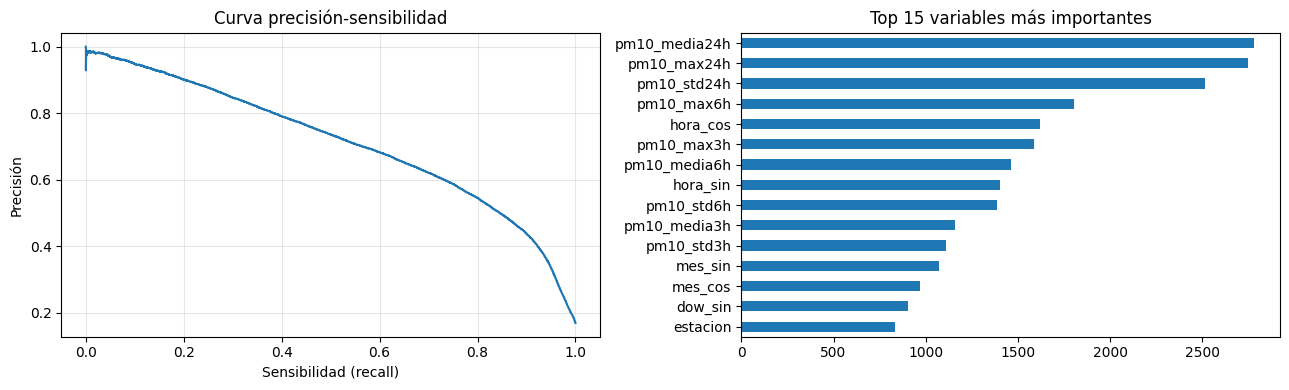

In [ ]:
# Curva precisión-sensibilidad e importancia de variables
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
pr, rc, _ = precision_recall_curve(yte, proba)
ax[0].plot(rc, pr); ax[0].set_xlabel("Sensibilidad (recall)")
ax[0].set_ylabel("Precisión"); ax[0].set_title("Curva precisión-sensibilidad")
ax[0].grid(alpha=.3)

imp = pd.Series(clf.feature_importances_, index=feat_cols).sort_values().tail(15)
imp.plot.barh(ax=ax[1]); ax[1].set_title("Top 15 variables más importantes")
plt.tight_layout(); plt.show()

### 19.7 Perfil de anticipación: ¿en cuántos minutos? (multi-horizonte)
Enfoque **2** de la Sección 19.4. Entrenamos el mismo LightGBM para varios
horizontes (15, 30, 60, 120 min) y vemos cómo cambian el **PR-AUC / ROC-AUC** y la
**tasa de excedencia** según cuánto se quiera anticipar. La curva aproxima la
respuesta a "¿en cuántos minutos?": el horizonte donde la señal aún es predecible
(PR-AUC alto) indica hasta dónde vale la pena avisar.


Rendimiento por horizonte de anticipación:


,horizonte_min,pct_positivos,roc_auc,pr_auc
0,15,5.73,0.952,0.629
1,30,8.24,0.940,0.657
2,60,11.85,0.925,0.683
3,120,16.95,0.908,0.712


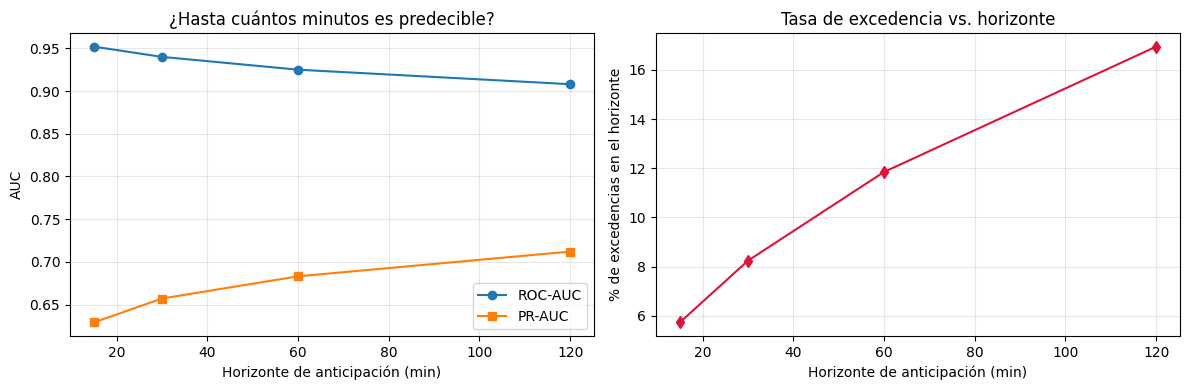

In [ ]:
resultados = []
proba_h = {}
for Hmin in HORIZONTES_MIN:
    col = f"y_{Hmin}"
    tb  = tabla[tabla[col].notna()]
    tr  = tb[tb.index <  CORTE]
    te  = tb[tb.index >= CORTE]
    m = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                           subsample=0.8, colsample_bytree=0.8,
                           class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
    m.fit(tr[feat_cols], tr[col].astype(int), categorical_feature=["estacion"])
    pb = m.predict_proba(te[feat_cols])[:, 1]
    proba_h[Hmin] = (te.index, pb)
    resultados.append(dict(
        horizonte_min = Hmin,
        pct_positivos = round(te[col].mean() * 100, 2),
        roc_auc       = round(roc_auc_score(te[col].astype(int), pb), 3),
        pr_auc        = round(average_precision_score(te[col].astype(int), pb), 3),
    ))

res = pd.DataFrame(resultados)
print("Rendimiento por horizonte de anticipación:")
display(res)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(res["horizonte_min"], res["roc_auc"], "o-", label="ROC-AUC")
ax[0].plot(res["horizonte_min"], res["pr_auc"],  "s-", label="PR-AUC")
ax[0].set_xlabel("Horizonte de anticipación (min)"); ax[0].set_ylabel("AUC")
ax[0].set_title("¿Hasta cuántos minutos es predecible?"); ax[0].grid(alpha=.3); ax[0].legend()
ax[1].plot(res["horizonte_min"], res["pct_positivos"], "d-", color="crimson")
ax[1].set_xlabel("Horizonte de anticipación (min)"); ax[1].set_ylabel("% de excedencias en el horizonte")
ax[1].set_title("Tasa de excedencia vs. horizonte"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


### 19.8 Guardado
Guardamos el modelo y las métricas (`auc_lgbm`, `pr_lgbm`) del horizonte principal

In [ ]:
import joblib
joblib.dump(clf, "modelo_alerta_lightgbm.pkl")

auc_lgbm = roc_auc_score(yte, proba)
pr_lgbm  = average_precision_score(yte, proba)

# Define H_HORAS based on HORIZONTE_MIN
H_HORAS = HORIZONTE_MIN // 60

print("Modelo guardado: modelo_alerta_lightgbm.pkl")
print("\nRESUMEN — MODELO BASE (LightGBM)")
print("-" * 45)
print("Estaciones activas (alerta):", estaciones_activas)
print(f"Horizonte de alerta        : {H_HORAS} h")
print(f"Límites internos usados    : {LIMITES}")
print(f"ROC-AUC / PR-AUC           : {auc_lgbm:.3f} / {pr_lgbm:.3f}")
print("\nAjusta el UMBRAL de alerta según el equilibrio precisión/sensibilidad necesaria.")

Modelo guardado: modelo_alerta_lightgbm.pkl

RESUMEN — MODELO BASE (LightGBM)
---------------------------------------------
Estaciones activas (alerta): ['CA-01 Cruce Collapampa', 'CA-02 Ovalo Musical', 'CA-04 TMF']
Horizonte de alerta        : 2 h
Límites internos usados    : {'CA-01 Cruce Collapampa': 300.0, 'CA-02 Ovalo Musical': 400.0, 'CA-03 Pampacancha': 100.0, 'CA-04 TMF': 300}
ROC-AUC / PR-AUC           : 0.908 / 0.712

Ajusta el UMBRAL de alerta según el equilibrio precisión/sensibilidad necesaria.


## 5. Relación Generador-Receptor: Constancia vs. OEFA (Chilloroya)

Finalmente, abordamos la dimensión del impacto externo. Comparamos la dinámica de nuestras estaciones internas (generador) con las mediciones oficiales de la red OEFA ubicadas en la Comunidad Campesina Chilloroya (receptor).

Identificar si existe una relación directa entre nuestros picos de emisión y la calidad del aire en la comunidad es fundamental para respaldar técnicamente nuestras comunicaciones, evaluar posibles impactos en pastizales y recursos locales, y mantener un monitoreo participativo transparente.

El presente cuaderno de análisis tiene como objetivo evaluar, procesar y contrastar los registros de concentración de material particulado ($PM_{10}$ y $PM_{2.5}$) correspondientes al año calendario 2025. El estudio integra y sincroniza bases de datos oficiales de las estaciones de monitoreo de la Unidad Minera (UMC) —ubicadas estratégicamente en **Pampacancha**, **Óvalo Musical** y **Collapampa**— con la estación de control externo gestionada por el Organismo de Evaluación y Fiscalización Ambiental (**OEFA**) en la Comunidad Campesina de **Chilloroya**.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargar OEFA (añadiendo encoding y manejo de líneas con errores)
df_oefa = pd.read_csv(
    'OEFA_Chilloroya_FebDic2025.csv',
    encoding='latin1',
    on_bad_lines='skip',
    engine='python',
)

# 2. Cargar UMC
df_umc = pd.read_csv('Data_horaria_diaria 2026 (1).csv', sep=';', encoding='latin1')

# 3. Limpieza de Nombres de Columnas
df_oefa = df_oefa.rename(columns={'PM10_UGM3': 'PM10_OEFA'})
df_umc = df_umc.rename(
    columns={
        'CA-01 Cruce Collapampa > Parameters > PM10 (Âµg/mÂ³)': 'PM10_COLLAPAMPA',
        'CA-03 Pampacancha > Parameters > PM10': 'PM10_PAMPACANCHA',
    }
)

# 4. Estandarización Temporal (Crear variable 'Hora')
df_oefa['Hora'] = pd.to_datetime(
    df_oefa['HORA_DATA'], format='%H:%M:%S', errors='coerce'
).dt.hour
df_umc['Hora'] = pd.to_datetime(
    df_umc.iloc[:, 1], format='%H:%M:%S', errors='coerce'
).dt.hour

print('Datos procesados correctamente. Columnas listas para análisis.')

/tmp/ipykernel_1814/1443313550.py:13: DtypeWarning: Columns (0,1,2,3,4,6,7,8,9,11,12,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_umc = pd.read_csv('Data_horaria_diaria 2026 (1).csv', sep=';', encoding='latin1')


Datos procesados correctamente. Columnas listas para análisis.


/tmp/ipykernel_1814/4183311562.py:13: DtypeWarning: Columns (0,1,2,3,4,6,7,8,9,11,12,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_umc = pd.read_csv(


Columna UMC Collapampa PM10: CA-01 Cruce Collapampa > Parameters > PM10 (Âµg/mÂ³)
Columna UMC Óvalo Musical PM10: CA-02 Ovalo Musical > Parameters > PM10 (Âµg/mÂ³)
Columna UMC Pampacancha PM10: CA-03 Pampacancha > Parameters > PM10


/tmp/ipykernel_1814/4183311562.py:61: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_umc['FECHA_COMPLETA'] = pd.to_datetime(


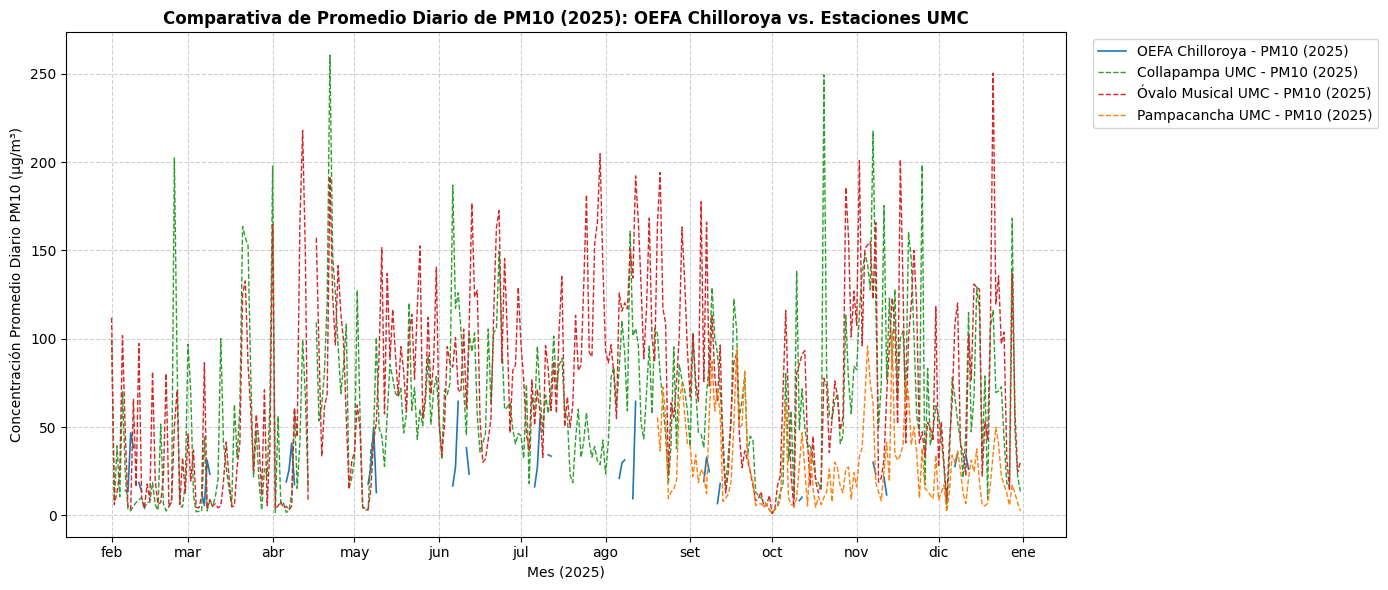

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd

# 1. Cargar archivos
df_oefa = pd.read_csv(
    'OEFA_Chilloroya_FebDic2025.csv',
    encoding='latin1',
    on_bad_lines='skip',
    engine='python',
)
df_umc = pd.read_csv(
    'Data_horaria_diaria 2026 (1).csv', sep=';', encoding='latin1'
)

# Limpiar espacios en los nombres de las columnas
df_oefa.columns = df_oefa.columns.str.strip()
df_umc.columns = df_umc.columns.str.strip()

# 2. Definir columna exacta para OEFA y búsqueda automática para UMC
col_fecha_oefa = 'FECHA_DATA'
col_oefa_pm10 = 'PM10_UGM3'

col_fecha_umc = df_umc.columns[0]
col_colla_pm10 = next(
    (
        c
        for c in df_umc.columns
        if 'Collapampa' in c and ('PM10' in c or 'PM_10' in c)
    ),
    None,
)
col_ovalo_pm10 = next(
    (
        c
        for c in df_umc.columns
        if ('Ovalo' in c or 'Óvalo' in c) and ('PM10' in c or 'PM_10' in c)
    ),
    None,
)
col_pampa_pm10 = next(
    (
        c
        for c in df_umc.columns
        if 'Pampacancha' in c and ('PM10' in c or 'PM_10' in c)
    ),
    None,
)

print('Columna UMC Collapampa PM10:', col_colla_pm10)
print('Columna UMC Óvalo Musical PM10:', col_ovalo_pm10)
print('Columna UMC Pampacancha PM10:', col_pampa_pm10)

# 3. Conversión de fechas y limpieza numérica
df_oefa['FECHA_COMPLETA'] = pd.to_datetime(
    df_oefa[col_fecha_oefa], errors='coerce'
)
df_oefa[col_oefa_pm10] = pd.to_numeric(df_oefa[col_oefa_pm10], errors='coerce')

df_umc['FECHA_COMPLETA'] = pd.to_datetime(
    df_umc[col_fecha_umc], errors='coerce'
)
for col in [col_colla_pm10, col_ovalo_pm10, col_pampa_pm10]:
  if col:
    df_umc[col] = pd.to_numeric(df_umc[col], errors='coerce')

# 4. Filtrar para el año 2025 (Feb - Dic) y descartar valores negativos en OEFA
start_date = '2025-02-01'
end_date = '2025-12-31 23:59:59'

mask_oefa = (
    (df_oefa['FECHA_COMPLETA'] >= start_date)
    & (df_oefa['FECHA_COMPLETA'] <= end_date)
    & (df_oefa[col_oefa_pm10] >= 0)
)
mask_umc = (df_umc['FECHA_COMPLETA'] >= start_date) & (
    df_umc['FECHA_COMPLETA'] <= end_date
)

df_oefa_2025 = df_oefa.loc[mask_oefa].copy()
df_umc_2025 = df_umc.loc[mask_umc].copy()

# 5. Agrupar por día para obtener promedios diarios
df_oefa_2025.set_index('FECHA_COMPLETA', inplace=True)
oefa_diario = df_oefa_2025[col_oefa_pm10].resample('D').mean()

df_umc_2025.set_index('FECHA_COMPLETA', inplace=True)
colla_diario = (
    df_umc_2025[col_colla_pm10].resample('D').mean()
    if col_colla_pm10
    else pd.Series()
)
ovalo_diario = (
    df_umc_2025[col_ovalo_pm10].resample('D').mean()
    if col_ovalo_pm10
    else pd.Series()
)
pampa_diario = (
    df_umc_2025[col_pampa_pm10].resample('D').mean()
    if col_pampa_pm10
    else pd.Series()
)

# 6. Generar la gráfica multiserie temporal con eje X formateado por mes
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    oefa_diario.index,
    oefa_diario.values,
    linestyle='-',
    linewidth=1.2,
    color='#1f77b4',
    label='OEFA Chilloroya - PM10 (2025)',
)
if not colla_diario.empty:
  ax.plot(
      colla_diario.index,
      colla_diario.values,
      linestyle='--',
      linewidth=1,
      color='#2ca02c',
      label='Collapampa UMC - PM10 (2025)',
  )
if not ovalo_diario.empty:
  ax.plot(
      ovalo_diario.index,
      ovalo_diario.values,
      linestyle='--',
      linewidth=1,
      color='#d62728',
      label='Óvalo Musical UMC - PM10 (2025)',
  )
if not pampa_diario.empty:
  ax.plot(
      pampa_diario.index,
      pampa_diario.values,
      linestyle='--',
      linewidth=1,
      color='#ff7f0e',
      label='Pampacancha UMC - PM10 (2025)',
  )

# Configuración del eje X para mostrar los meses en español (ene, feb, mar...)
ax.xaxis.set_major_locator(mdates.MonthLocator())


def month_formatter(x, pos):
  date = mdates.num2date(x)
  meses_es = [
      '',
      'ene',
      'feb',
      'mar',
      'abr',
      'may',
      'jun',
      'jul',
      'ago',
      'set',
      'oct',
      'nov',
      'dic',
  ]
  return meses_es[date.month] if 1 <= date.month <= 12 else ''


ax.xaxis.set_major_formatter(FuncFormatter(month_formatter))

ax.set_title(
    'Comparativa de Promedio Diario de PM10 (2025): OEFA Chilloroya vs.'
    ' Estaciones UMC',
    fontsize=12,
    fontweight='bold',
)
ax.set_xlabel('Mes (2025)', fontsize=10)
ax.set_ylabel('Concentración Promedio Diario PM10 (µg/m³)', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1814/344592211.py:13: DtypeWarning: Columns (0,1,2,3,4,6,7,8,9,11,12,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_umc = pd.read_csv(
/tmp/ipykernel_1814/344592211.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_umc['FECHA_COMPLETA'] = pd.to_datetime(


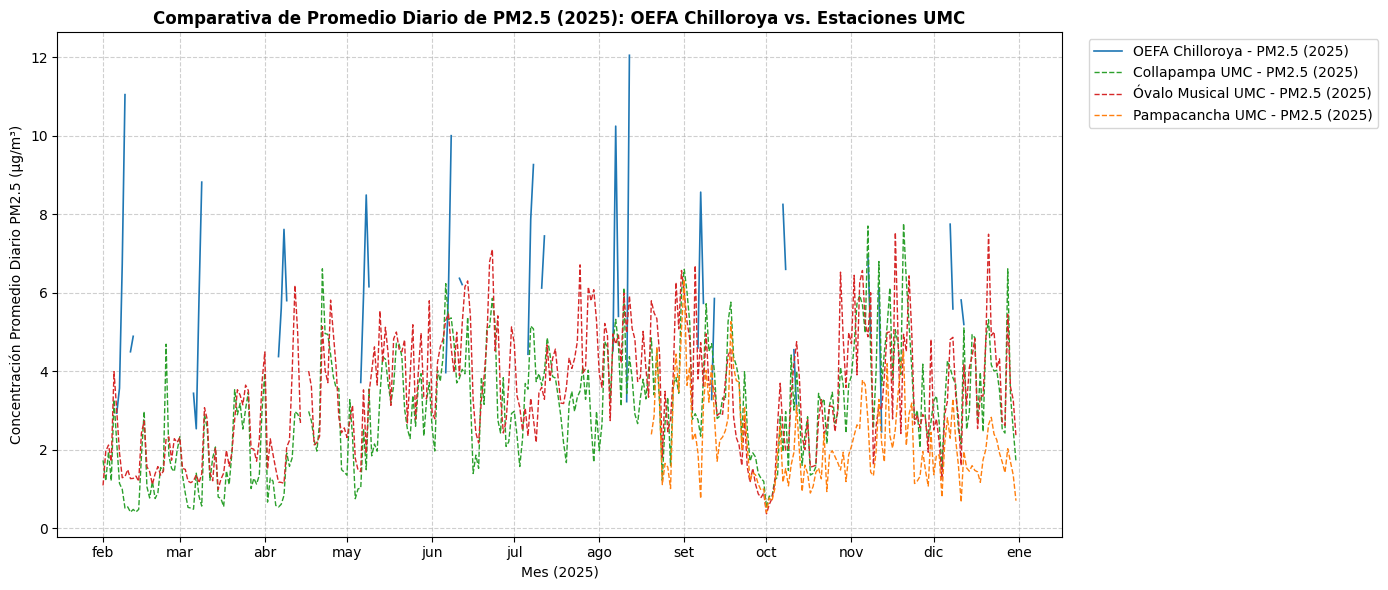

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd

# 1. Cargar archivos
df_oefa = pd.read_csv(
    'OEFA_Chilloroya_FebDic2025.csv',
    encoding='latin1',
    on_bad_lines='skip',
    engine='python',
)
df_umc = pd.read_csv(
    'Data_horaria_diaria 2026 (1).csv', sep=';', encoding='latin1'
)

# Limpiar espacios en los nombres de las columnas
df_oefa.columns = df_oefa.columns.str.strip()
df_umc.columns = df_umc.columns.str.strip()

# 2. Definir columnas exactas para OEFA y búsqueda automática para UMC
col_fecha_oefa = 'FECHA_DATA'
col_oefa_pm25 = 'PM25_UGM3'

col_fecha_umc = df_umc.columns[0]
col_colla_pm25 = next(
    (
        c
        for c in df_umc.columns
        if 'Collapampa' in c and ('PM2.5' in c or 'PM25' in c)
    ),
    None,
)
col_ovalo_pm25 = next(
    (
        c
        for c in df_umc.columns
        if ('Ovalo' in c or 'Óvalo' in c) and ('PM2.5' in c or 'PM25' in c)
    ),
    None,
)
col_pampa_pm25 = next(
    (
        c
        for c in df_umc.columns
        if 'Pampacancha' in c and ('PM2.5' in c or 'PM25' in c)
    ),
    None,
)

# 3. Conversión de fechas y limpieza numérica
df_oefa['FECHA_COMPLETA'] = pd.to_datetime(
    df_oefa[col_fecha_oefa], errors='coerce'
)
df_oefa[col_oefa_pm25] = pd.to_numeric(df_oefa[col_oefa_pm25], errors='coerce')

df_umc['FECHA_COMPLETA'] = pd.to_datetime(
    df_umc[col_fecha_umc], errors='coerce'
)
for col in [col_colla_pm25, col_ovalo_pm25, col_pampa_pm25]:
  if col:
    df_umc[col] = pd.to_numeric(df_umc[col], errors='coerce')

# 4. Filtrar para el año 2025 (Feb - Dic) y descartar valores negativos en OEFA
start_date = '2025-02-01'
end_date = '2025-12-31 23:59:59'

mask_oefa = (
    (df_oefa['FECHA_COMPLETA'] >= start_date)
    & (df_oefa['FECHA_COMPLETA'] <= end_date)
    & (df_oefa[col_oefa_pm25] >= 0)
)
mask_umc = (df_umc['FECHA_COMPLETA'] >= start_date) & (
    df_umc['FECHA_COMPLETA'] <= end_date
)

df_oefa_2025 = df_oefa.loc[mask_oefa].copy()
df_umc_2025 = df_umc.loc[mask_umc].copy()

# 5. Agrupar por día para obtener promedios diarios
df_oefa_2025.set_index('FECHA_COMPLETA', inplace=True)
oefa_diario = df_oefa_2025[col_oefa_pm25].resample('D').mean()

df_umc_2025.set_index('FECHA_COMPLETA', inplace=True)
colla_diario = (
    df_umc_2025[col_colla_pm25].resample('D').mean()
    if col_colla_pm25
    else pd.Series()
)
ovalo_diario = (
    df_umc_2025[col_ovalo_pm25].resample('D').mean()
    if col_ovalo_pm25
    else pd.Series()
)
pampa_diario = (
    df_umc_2025[col_pampa_pm25].resample('D').mean()
    if col_pampa_pm25
    else pd.Series()
)

# 6. Generar la gráfica multiserie temporal con eje X formateado por mes
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    oefa_diario.index,
    oefa_diario.values,
    linestyle='-',
    linewidth=1.2,
    color='#1f77b4',
    label='OEFA Chilloroya - PM2.5 (2025)',
)
if not colla_diario.empty:
  ax.plot(
      colla_diario.index,
      colla_diario.values,
      linestyle='--',
      linewidth=1,
      color='#2ca02c',
      label='Collapampa UMC - PM2.5 (2025)',
  )
if not ovalo_diario.empty:
  ax.plot(
      ovalo_diario.index,
      ovalo_diario.values,
      linestyle='--',
      linewidth=1,
      color='#d62728',
      label='Óvalo Musical UMC - PM2.5 (2025)',
  )
if not pampa_diario.empty:
  ax.plot(
      pampa_diario.index,
      pampa_diario.values,
      linestyle='--',
      linewidth=1,
      color='#ff7f0e',
      label='Pampacancha UMC - PM2.5 (2025)',
  )

# Configuración del eje X para mostrar los meses en español (ene, feb, mar...)
ax.xaxis.set_major_locator(mdates.MonthLocator())


def month_formatter(x, pos):
  date = mdates.num2date(x)
  meses_es = [
      '',
      'ene',
      'feb',
      'mar',
      'abr',
      'may',
      'jun',
      'jul',
      'ago',
      'set',
      'oct',
      'nov',
      'dic',
  ]
  return meses_es[date.month] if 1 <= date.month <= 12 else ''


ax.xaxis.set_major_formatter(FuncFormatter(month_formatter))

ax.set_title(
    'Comparativa de Promedio Diario de PM2.5 (2025): OEFA Chilloroya vs.'
    ' Estaciones UMC',
    fontsize=12,
    fontweight='bold',
)
ax.set_xlabel('Mes (2025)', fontsize=10)
ax.set_ylabel('Concentración Promedio Diario PM2.5 (µg/m³)', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Conclusiones: Relación Generador-Receptor (UM Constancia vs. Chilloroya)

A partir del análisis comparativo de las series de tiempo (2025) entre las estaciones internas de la operación y la estación de OEFA en la Comunidad Campesina de Chilloroya, se evidencian los siguientes patrones clave:

* **Dinámica del PM10 (Material Particulado Grueso):** Las estaciones internas (especialmente *Collapampa* y *Óvalo Musical*) registran una alta variabilidad y picos frecuentes que superan los 150 µg/m³, lo cual es congruente con su cercanía a las vías de acarreo y el tránsito de flota pesada. Sin embargo, la estación OEFA Chilloroya mantiene niveles consistentemente más bajos (predominantemente por debajo de los 75 µg/m³) y no replica las excedencias de la mina. Esto demuestra que las partículas gruesas se asientan rápidamente dentro de la huella operativa y **no existe un transporte significativo de PM10 desde la unidad minera hacia la comunidad**.

* **Comportamiento del PM2.5 (Material Particulado Fino):** Se observa una dinámica inversa al PM10. La estación OEFA Chilloroya presenta picos agudos y aislados (alcanzando entre 8 y 12 µg/m³) que **no tienen correlación temporal** con las estaciones internas de la U.M. Constancia, las cuales se mantienen estables y con valores más bajos. Esto sugiere fuertemente que los incrementos de PM2.5 en la comunidad responden a **fuentes de emisión locales** (como actividades domésticas, quema de biomasa o tránsito vehicular local) y no a la dispersión de emisiones desde la vía de acarreo.

* **Impacto de la Estacionalidad:** Ambas gráficas ratifican el efecto del factor estacional. La dispersión y los picos de concentración (particularmente de PM10 interno) se acentúan notablemente durante la temporada seca (mayo a noviembre). Hacia el final del año, el inicio de la temporada de lluvias y la presencia de tormentas eléctricas actúan como un supresor natural efectivo, reduciendo drásticamente la resuspensión de polvo y estabilizando las mediciones en todas las estaciones.

* **Oportunidad en la captura de datos (Data Gaps):** Es importante notar desde el punto de vista del análisis de datos que la serie de tiempo de la estación OEFA Chilloroya presenta discontinuidades (vacíos de información). Para futuros modelos predictivos o cálculos de correlación estadística de Pearson/Spearman, estos periodos sin medición deberán ser imputados o excluidos del *dataset* para evitar sesgos en el indicador de precisión.